# Spectral Feature Difficulty Analysis — Per Experiment
Companion to `feature_difficulty_analysis.ipynb`. That notebook asked which **molecular** features make test compounds
hard to elucidate; this one asks the same question of the **input EI spectra**.

* Outcomes are identical to the molecular notebook: top-1/5/10 hit (InChI match after count-ranking valid candidates)
  and top-1 Morgan Tanimoto similarity.
* The prediction shards only store `(pred_mols, true_mol)`, so each test molecule is linked back to its NEIMS spectrum
  **by structure** (canonical SMILES, falling back to InChIKey for tautomers such as amide ↔ imidic acid that change
  during graph reconstruction).
* Each experiment is analysed independently (the test sets overlap).

Sections
1. Load predictions and per-molecule outcomes
2. Link test molecules to spectra
3. Interpretable spectral features
4. Hit vs miss distributions
5. Cross-experiment effect-size summary
6. Top-1 Tanimoto correlations
7. Are the spectral effects just molecular size? (partial correlations, MW-stratified hit rates)
8. Predictive value: molecular vs spectral vs combined features
9. Spectral space: PCA + k-means of binned spectra
10. Spectral novelty and ambiguity: nearest neighbours in the training library
11. Example spectra: hits vs misses of similar mass
12. Save results
13. Findings

In [1]:
import sys, os, warnings, pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw, AllChem, DataStructs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_predict
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.inspection import permutation_importance
from scipy import stats

sys.path.insert(0, '..')
from src.utils import is_valid

RDLogger.DisableLog('rdApp.*')
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

EXP_BASE  = 'data/new_experiments'
SPEC_PKL  = '../data/gecko_new_mixed_augment_atmomaccs_test/df_neims_gecko_new_mixed_augment_atmomaccs_test_3_9_22.pkl'
OUT_DIR   = 'spectral_difficulty_analysis'
PLOT_DPI  = 150
HIT_COLOR, MISS_COLOR = '#4a90d9', '#e05c5c'
os.makedirs(OUT_DIR, exist_ok=True)

# Name prefixes in the collated spectrum pickle
TEST_PREFIXES = ['wang', 'ferraz-caetano', 'li', 'kruger-confined']   # experimental-structure test sets
REF_PREFIXES  = ['gecko_new', 'mix_aug']                              # training libraries

fs = 11
plt.rcParams.update({'font.size': fs})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']

def sig_stars(p):
    return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))

print('Setup complete.')

Setup complete.


## 1. Load experiment predictions and per-molecule outcomes
Same loading and scoring logic as the molecular notebook. Candidates are discarded after scoring to save memory; the per-molecule outcomes are cached in `OUT_DIR`.

In [2]:
def load_exp(exp_dir, pred_prefix='dev_pred', true_prefix='dev_true'):
    '''Load all pred/true pkl shards from an experiment directory.'''
    pred_files = sorted(
        [f for f in os.listdir(exp_dir) if f.startswith(pred_prefix) and f.endswith('.pkl')],
        key=lambda f: int(f.split('_')[-1].replace('.pkl', ''))
    )
    all_preds, all_trues = [], []
    for pf in pred_files:
        tf = pf.replace(pred_prefix, true_prefix)
        with open(os.path.join(exp_dir, pf), 'rb') as fh:
            all_preds.extend(pkl.load(fh))
        with open(os.path.join(exp_dir, tf), 'rb') as fh:
            all_trues.extend(pkl.load(fh))
    return all_preds, all_trues

def mol_hit_flags(pred_mols, true_mol, k_list=(1, 5, 10)):
    '''Same logic as K_ACC_Collection.update(): valid → InChI → rank by count → membership at k.'''
    true_inchi = Chem.MolToInchi(true_mol)
    inchis = [Chem.MolToInchi(mol) for mol in pred_mols if is_valid(mol)]
    ranked = [inchi for inchi, _ in Counter(inchis).most_common()]
    return {k: true_inchi in ranked[:k] for k in k_list}

def top1_tanimoto(pred_mols, true_mol):
    '''Same logic as K_TanimotoSimilarity(k=1).update(): Morgan r=2, 2048 bits, top-1 candidate.'''
    true_fp = AllChem.GetMorganFingerprintAsBitVect(true_mol, 2, nBits=2048)
    max_sim = 0.0
    for mol in pred_mols[:1]:
        try:
            gen_fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
            max_sim = max(max_sim, DataStructs.TanimotoSimilarity(gen_fp, true_fp))
        except Exception:
            pass
    return max_sim

EXP_CONFIGS = {
    'Exp1: Only Gecko': dict(exp_dir=f'{EXP_BASE}/exp1'),
    'Exp2: Only Augmented': dict(exp_dir=f'{EXP_BASE}/exp2', pred_prefix='dev_resume_pred', true_prefix='dev_resume_true'),
    'Exp3: Augmented + Gecko (sequential)': dict(exp_dir=f'{EXP_BASE}/exp3'),
    'Exp4: Augmented + Gecko (parallel)': dict(exp_dir=f'{EXP_BASE}/exp4', pred_prefix='dev_resume_pred', true_prefix='dev_resume_true'),
}

OUTCOME_CACHE = f'{OUT_DIR}/outcomes_cache.pkl'
if os.path.exists(OUTCOME_CACHE):
    with open(OUTCOME_CACHE, 'rb') as fh:
        exp_outcomes = pkl.load(fh)
    print(f'Loaded cached outcomes from {OUTCOME_CACHE}')
else:
    exp_outcomes = {}
    for exp_name, cfg in EXP_CONFIGS.items():
        preds, trues = load_exp(**cfg)
        rows = []
        for p, t in zip(preds, trues):
            flags = mol_hit_flags(p, t)
            rows.append({'true_smiles': Chem.MolToSmiles(t),
                         'true_inchikey': Chem.MolToInchiKey(t),
                         'hit_top1': flags[1], 'hit_top5': flags[5], 'hit_top10': flags[10],
                         'tanimoto_top1': top1_tanimoto(p, t)})
        exp_outcomes[exp_name] = pd.DataFrame(rows)
        del preds, trues
    with open(OUTCOME_CACHE, 'wb') as fh:
        pkl.dump(exp_outcomes, fh)

for exp_name, odf in exp_outcomes.items():
    print(f'{exp_name}: n={len(odf):,}  top1={odf.hit_top1.mean():.4f}  top10={odf.hit_top10.mean():.4f}  '
          f'tanimoto_top1_mean={odf.tanimoto_top1.mean():.4f}')

Loaded cached outcomes from spectral_difficulty_analysis/outcomes_cache.pkl
Exp1: Only Gecko: n=6,682  top1=0.0218  top10=0.0670  tanimoto_top1_mean=0.1732
Exp2: Only Augmented: n=7,548  top1=0.0241  top10=0.0808  tanimoto_top1_mean=0.1594
Exp3: Augmented + Gecko (sequential): n=7,548  top1=0.0356  top10=0.1036  tanimoto_top1_mean=0.1828
Exp4: Augmented + Gecko (parallel): n=7,548  top1=0.0405  top10=0.1271  tanimoto_top1_mean=0.2073


## 2. Link test molecules to their spectra
The collated NEIMS pickle holds `(SMILES, spec, name)`; `spec` is an `(n_peaks, 2)` array of unit-mass m/z and
intensity (base peak = 999). Test spectra come from the four experimental-structure sets; the `gecko_new` and
`mix_aug` rows are the training libraries (used in Section 10).

Linkage: canonical SMILES → spectrum; if that fails, InChIKey (standard InChI normalises mobile-H tautomers).

In [3]:
spec_df = pd.read_pickle(SPEC_PKL)
spec_df['prefix'] = spec_df['name'].str.rsplit('_', n=1).str[0]
print(spec_df['prefix'].value_counts().to_string())

test_spec = spec_df[spec_df['prefix'].isin(TEST_PREFIXES)].reset_index(drop=True)
test_spec['mol'] = [Chem.MolFromSmiles(s) for s in test_spec['SMILES']]
test_spec = test_spec[test_spec['mol'].notna()].reset_index(drop=True)
test_spec['can'] = [Chem.MolToSmiles(m) for m in test_spec['mol']]
test_spec['inchikey'] = [Chem.MolToInchiKey(m) for m in test_spec['mol']]

can_to_idx = {s: i for i, s in enumerate(test_spec['can'])}
ik_to_idx  = {k: i for i, k in enumerate(test_spec['inchikey'])}

def link_to_spectrum(odf):
    idx, how = [], []
    for s, k in zip(odf['true_smiles'], odf['true_inchikey']):
        if s in can_to_idx:
            idx.append(can_to_idx[s]); how.append('smiles')
        elif k in ik_to_idx:
            idx.append(ik_to_idx[k]); how.append('inchikey')
        else:
            idx.append(-1); how.append('unmatched')
    return np.array(idx), np.array(how)

link_rows = []
for exp_name, odf in exp_outcomes.items():
    idx, how = link_to_spectrum(odf)
    odf['spec_idx'], odf['link'] = idx, how
    c = Counter(how)
    link_rows.append({'Experiment': exp_name, 'n': len(odf), **c,
                      'coverage': 1 - c['unmatched'] / len(odf),
                      'hit10 (matched)': odf.loc[idx >= 0, 'hit_top10'].mean(),
                      'hit10 (unmatched)': odf.loc[idx < 0, 'hit_top10'].mean()})
display(pd.DataFrame(link_rows).round(4))

mix_aug            290993
gecko_new          176624
wang                 3171
ferraz-caetano       2296
li                   1544
kruger-confined       539


,Experiment,n,smiles,unmatched,inchikey,coverage,hit10 (matched),hit10 (unmatched)
0,Exp1: Only Gecko,6682,6522,48,112,0.9928,0.0674,0.0208
1,Exp2: Only Augmented,7548,7380,48,120,0.9936,0.0812,0.0208
2,Exp3: Augmented + Gecko (sequential),7548,7380,48,120,0.9936,0.1043,0.0000
3,Exp4: Augmented + Gecko (parallel),7548,7380,48,120,0.9936,0.1277,0.0208


## 3. Interpretable spectral features
Computed on the relative spectrum (base peak = 1). *M* is the nominal mass of the molecular ion (most-abundant
isotopes), i.e. where the M⁺· peak should be.

| Feature | Meaning | Why it may matter |
|---|---|---|
| `nPeaks`, `nPeaks_5pct` | non-zero peaks / peaks ≥ 5 % | information content |
| `nPeaks_HighMass` | peaks ≥ 1 % above M/2 | large fragments constrain the skeleton |
| `M_rel_inten` | M⁺· intensity (% of base) | no molecular ion → formula/size is ambiguous |
| `MaxMz_frac` | highest ≥ 1 % peak / M | how far the observed spectrum reaches toward M |
| `BasePeakMz`, `BasePeak_frac` | base-peak m/z (absolute, relative to M) | small base peaks are generic |
| `WeightedMz_frac` | intensity-weighted mean m/z / M | where the signal sits |
| `HighMass_inten_frac` | intensity fraction above M/2 | |
| `LowMz_inten_frac` | intensity fraction below m/z 50 | small, non-specific ions |
| `Top1_inten_frac`, `Top5_inten_frac` | intensity concentration | one dominant ion vs. rich pattern |
| `Entropy`, `NormEntropy` | Shannon entropy (nats), entropy / ln(nPeaks) | spectral complexity/flatness |
| `Generic_inten_frac` | intensity at ubiquitous EI ions (15, 26–29, 31, 39, 41–45, 55, 57, 69, 77, 91) | uninformative signal |
| `NOx_inten_frac` | intensity at m/z 30 (NO⁺) and 46 (NO₂⁺) | nitrate/nitro marker (N–O groups were hard structurally) |
| `EvenMz_inten_frac` | intensity on even m/z | nitrogen rule / odd-electron rearrangement ions |

Molecular descriptors (same panel as the molecular notebook) are computed on the true molecule for confound control.

In [4]:
GENERIC_IONS = np.array([15, 26, 27, 28, 29, 31, 39, 41, 42, 43, 44, 45, 55, 57, 69, 77, 91])
NOX_IONS     = np.array([30, 46])
PT = Chem.GetPeriodicTable()

SPEC_COLS = ['nPeaks', 'nPeaks_5pct', 'nPeaks_HighMass', 'M_rel_inten', 'MaxMz_frac',
             'BasePeakMz', 'BasePeak_frac', 'WeightedMz_frac', 'HighMass_inten_frac', 'LowMz_inten_frac',
             'Top1_inten_frac', 'Top5_inten_frac', 'Entropy', 'NormEntropy',
             'Generic_inten_frac', 'NOx_inten_frac', 'EvenMz_inten_frac']

def nominal_mass(mol):
    return int(sum(PT.GetMostCommonIsotope(a.GetAtomicNum()) + a.GetTotalNumHs() for a in mol.GetAtoms()))

def compute_spectral_features(spec, M):
    spec = spec[spec[:, 1] > 0]            # some NEIMS spectra carry zero-intensity peaks
    mz  = spec[:, 0].astype(int)
    rel = spec[:, 1].astype(float) / spec[:, 1].max()
    p   = rel / rel.sum()
    sig = rel >= 0.01
    order = np.argsort(rel)[::-1]
    base_mz = mz[order[0]]
    ent = -(p * np.log(p)).sum()
    return {
        'NominalMass':         M,
        'nPeaks':              len(mz),
        'nPeaks_5pct':         int((rel >= 0.05).sum()),
        'nPeaks_HighMass':     int((sig & (mz > M / 2)).sum()),
        'M_rel_inten':         100 * rel[mz == M].sum(),
        'MaxMz_frac':          mz[sig].max() / M,
        'BasePeakMz':          base_mz,
        'BasePeak_frac':       base_mz / M,
        'WeightedMz_frac':     (p * mz).sum() / M,
        'HighMass_inten_frac': p[mz > M / 2].sum(),
        'LowMz_inten_frac':    p[mz < 50].sum(),
        'Top1_inten_frac':     p[order[:1]].sum(),
        'Top5_inten_frac':     p[order[:5]].sum(),
        'Entropy':             ent,
        'NormEntropy':         ent / np.log(len(mz)) if len(mz) > 1 else 0.0,
        'Generic_inten_frac':  p[np.isin(mz, GENERIC_IONS)].sum(),
        'NOx_inten_frac':      p[np.isin(mz, NOX_IONS)].sum(),
        'EvenMz_inten_frac':   p[mz % 2 == 0].sum(),
    }

DESC_KEYS = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'ArRings', 'NonArRings', 'AllRings', 'Fsp3',
             'nC', 'nO', 'nN', 'nHalogen', 'nS', 'FormalCharge', 'HeavyAtoms', 'O_C_ratio', 'N_C_ratio']
MOL_COLS  = [k for k in DESC_KEYS if k not in ('AllRings', 'FormalCharge')]

def compute_rdkit_descriptors(mol):
    '''Same panel as feature_difficulty_analysis.ipynb.'''
    n_ar = rdMolDescriptors.CalcNumAromaticRings(mol)
    n_r  = rdMolDescriptors.CalcNumRings(mol)
    n_c  = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 6)
    n_o  = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 8)
    n_n  = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 7)
    return {
        'MW': Descriptors.ExactMolWt(mol), 'LogP': Descriptors.MolLogP(mol),
        'TPSA': rdMolDescriptors.CalcTPSA(mol), 'HBD': rdMolDescriptors.CalcNumHBD(mol),
        'HBA': rdMolDescriptors.CalcNumHBA(mol), 'RotBonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
        'ArRings': n_ar, 'NonArRings': max(0, n_r - n_ar), 'AllRings': n_r,
        'Fsp3': rdMolDescriptors.CalcFractionCSP3(mol), 'nC': n_c, 'nO': n_o, 'nN': n_n,
        'nHalogen': sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() in (9, 17, 35, 53)),
        'nS': sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 16),
        'FormalCharge': Chem.rdmolops.GetFormalCharge(mol), 'HeavyAtoms': mol.GetNumHeavyAtoms(),
        'O_C_ratio': n_o / max(n_c, 1), 'N_C_ratio': n_n / max(n_c, 1),
    }

# Features are properties of the test spectrum/molecule, so compute them once per spectrum
spec_feat_df = pd.DataFrame([
    {**compute_spectral_features(s, nominal_mass(m)), **compute_rdkit_descriptors(m)}
    for s, m in zip(test_spec['spec'], test_spec['mol'])
])

# One analysis DataFrame per experiment (matched molecules only)
exp_dfs = {}
for exp_name, odf in exp_outcomes.items():
    m = odf[odf['spec_idx'] >= 0].reset_index(drop=True)
    adf = pd.concat([m, spec_feat_df.iloc[m['spec_idx']].reset_index(drop=True)], axis=1)
    exp_dfs[exp_name] = adf
    print(f'{exp_name}: n={len(adf):,}  hit10={adf.hit_top10.mean():.3f}  '
          f'M+ absent (<1%): {(adf.M_rel_inten < 1).mean():.1%}')

display(spec_feat_df[SPEC_COLS].describe().T.round(3))

Exp1: Only Gecko: n=6,634  hit10=0.067  M+ absent (<1%): 34.9%
Exp2: Only Augmented: n=7,500  hit10=0.081  M+ absent (<1%): 38.0%
Exp3: Augmented + Gecko (sequential): n=7,500  hit10=0.104  M+ absent (<1%): 38.0%
Exp4: Augmented + Gecko (parallel): n=7,500  hit10=0.128  M+ absent (<1%): 38.0%


,count,mean,std,min,25%,50%,75%,max
nPeaks,7550.0,74.266,46.027,5.000,44.000,61.000,89.000,474.000
nPeaks_5pct,7550.0,56.330,35.812,5.000,33.000,45.000,68.000,382.000
nPeaks_HighMass,7550.0,24.743,18.429,0.000,12.000,20.000,32.000,186.000
M_rel_inten,7550.0,27.473,34.520,0.000,0.000,10.611,47.848,100.000
MaxMz_frac,7550.0,0.934,0.118,0.339,0.875,1.003,1.010,1.188
BasePeakMz,7550.0,75.279,51.273,14.000,43.000,57.000,91.000,462.000
BasePeak_frac,7550.0,0.464,0.266,0.050,0.256,0.377,0.626,1.021
WeightedMz_frac,7550.0,0.444,0.118,0.148,0.365,0.429,0.513,0.992
HighMass_inten_frac,7550.0,0.331,0.201,0.000,0.177,0.301,0.463,1.000
LowMz_inten_frac,7550.0,0.348,0.217,0.000,0.162,0.314,0.504,1.000


## 4. Spectral feature distributions: hit vs miss
Effect size is the rank-biserial correlation *r* = 2U/(n₁n₂) − 1 (positive → larger in hits). With n ≈ 7 000, p-values are small for almost anything, so rank by |r|.

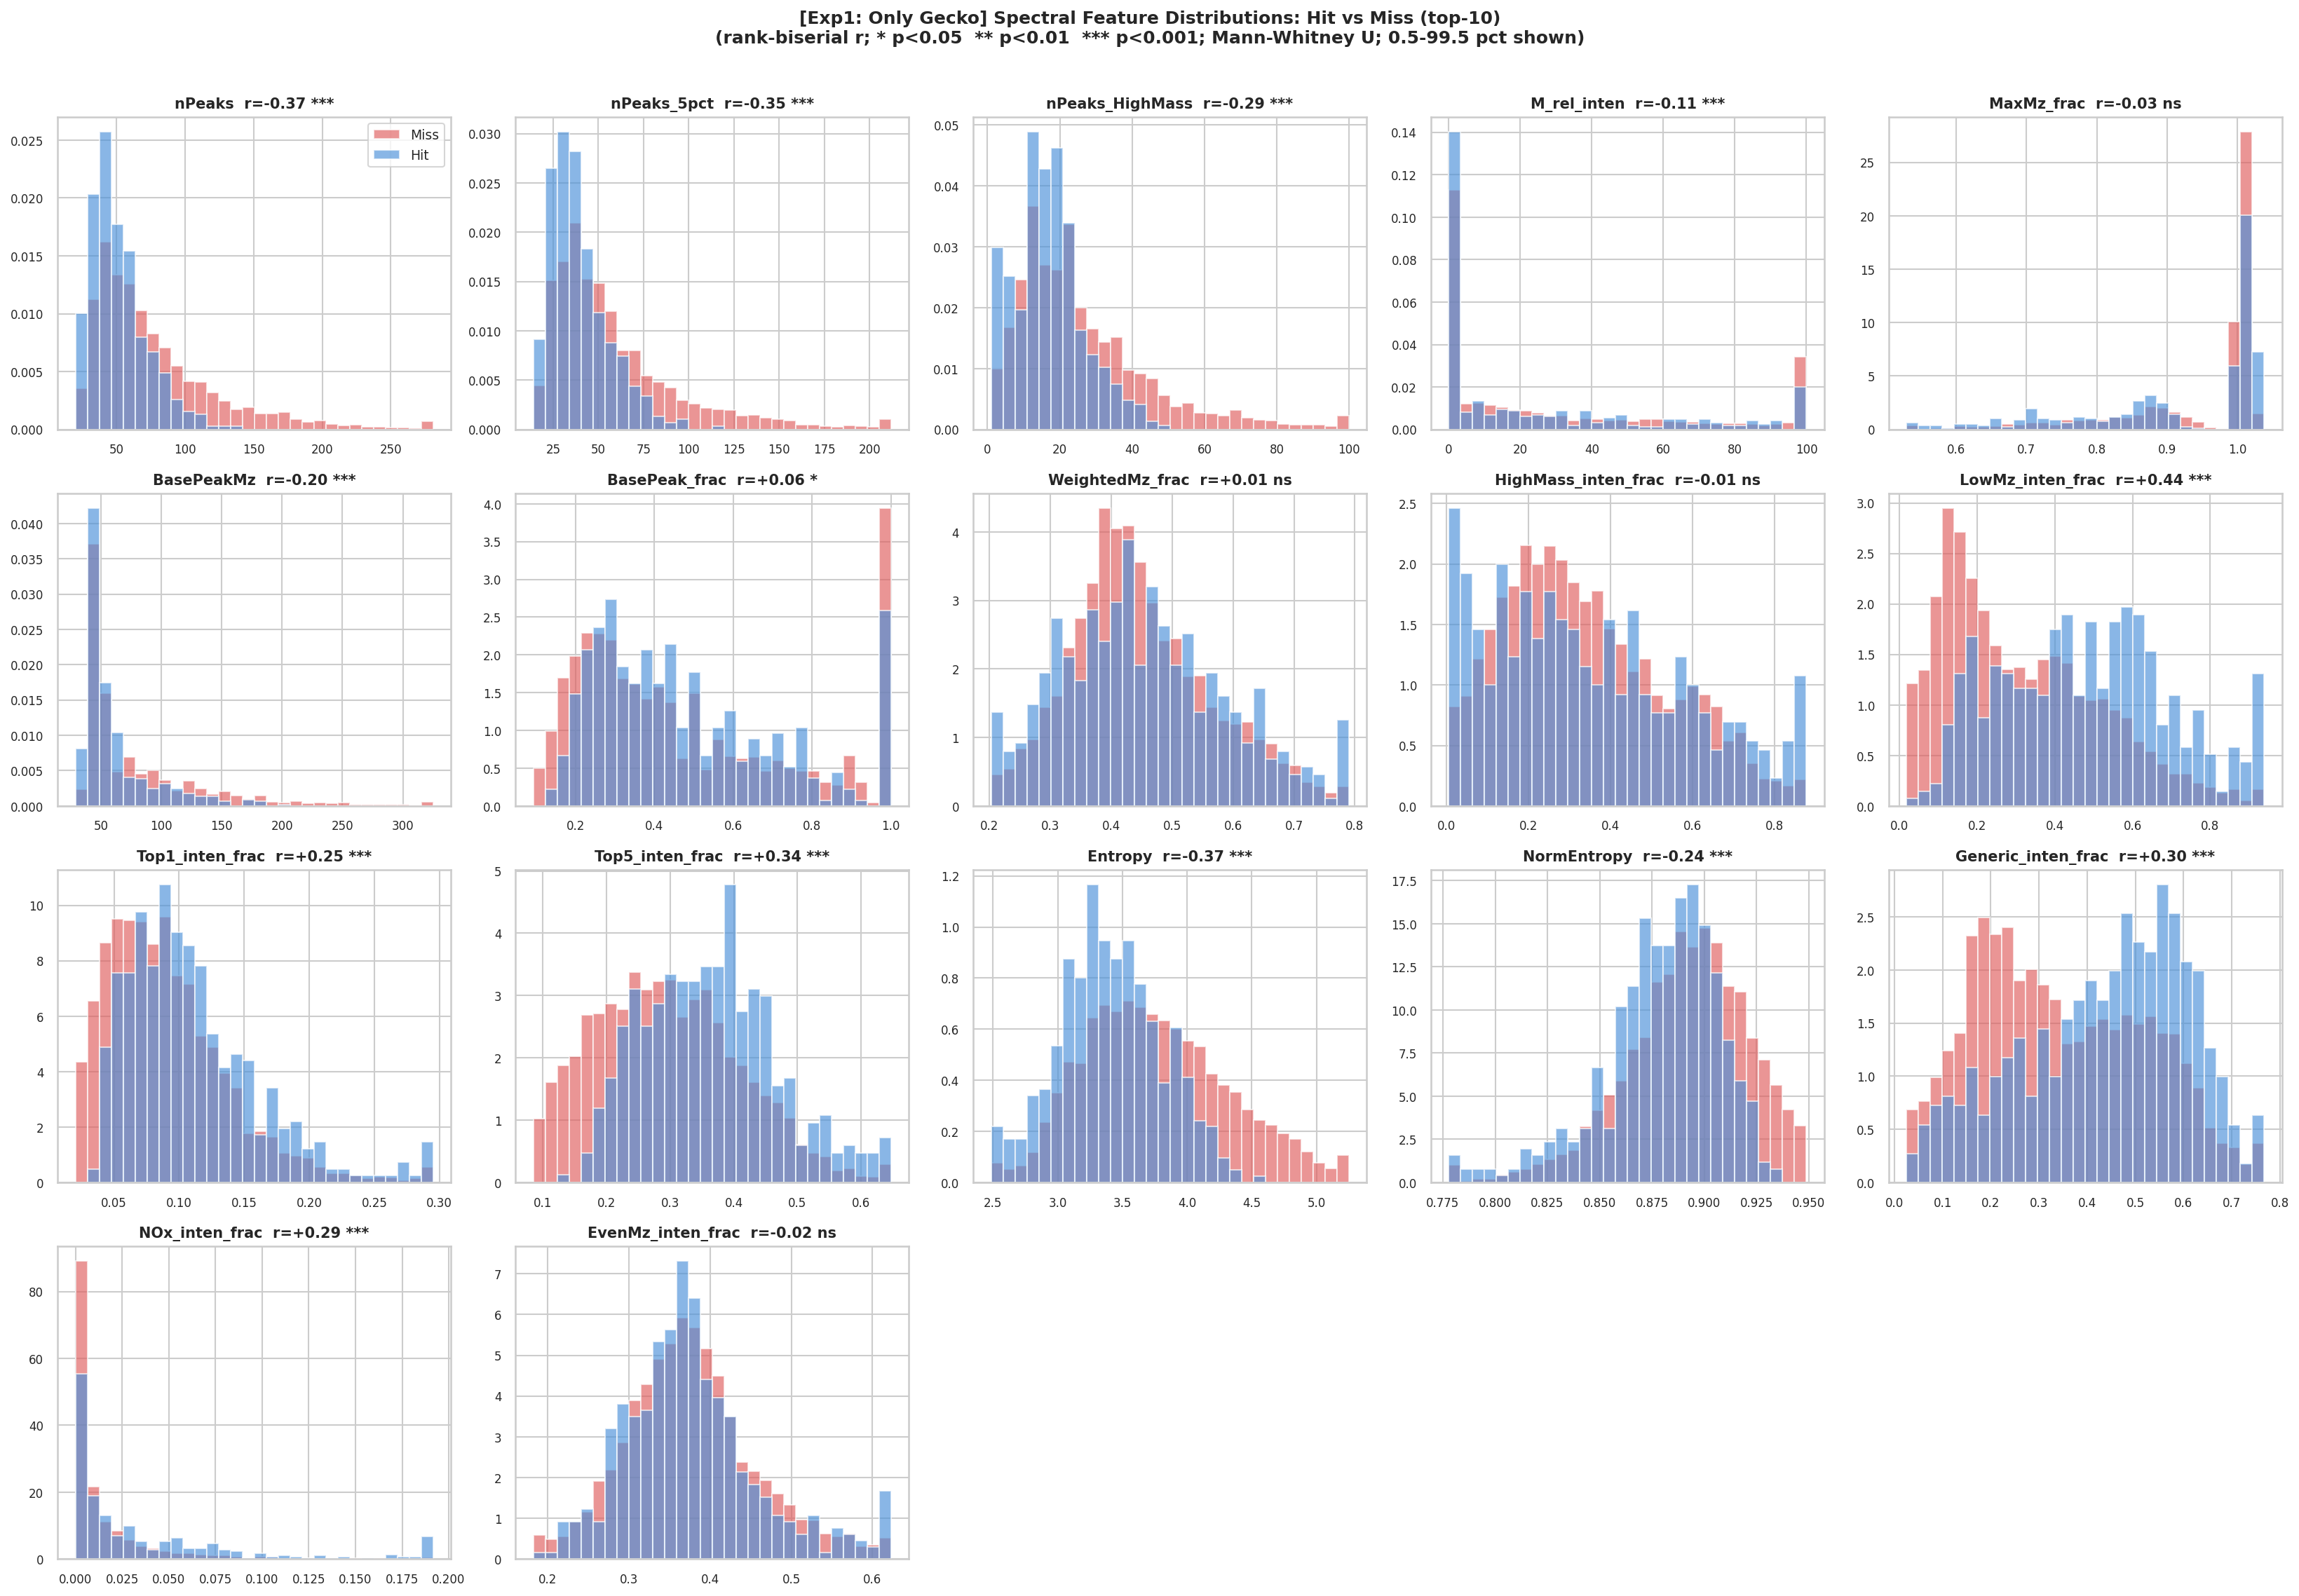


=== Exp1: Only Gecko ===


,Median (Hit),Median (Miss),Mean (Hit),Mean (Miss),r_rb,p-value
Feature,,,,,,
LowMz_inten_frac,0.486,0.269,0.483,0.314,0.437,0.000
nPeaks,48.000,64.000,51.371,77.989,-0.372,0.000
Entropy,3.395,3.709,3.401,3.761,-0.369,0.000
nPeaks_5pct,36.000,48.000,39.367,59.020,-0.347,0.000
Top5_inten_frac,0.360,0.287,0.365,0.296,0.340,0.000
Generic_inten_frac,0.468,0.319,0.438,0.345,0.301,0.000
nPeaks_HighMass,17.000,22.000,17.007,26.320,-0.292,0.000
NOx_inten_frac,0.014,0.004,0.039,0.014,0.290,0.000
Top1_inten_frac,0.099,0.082,0.111,0.090,0.246,0.000


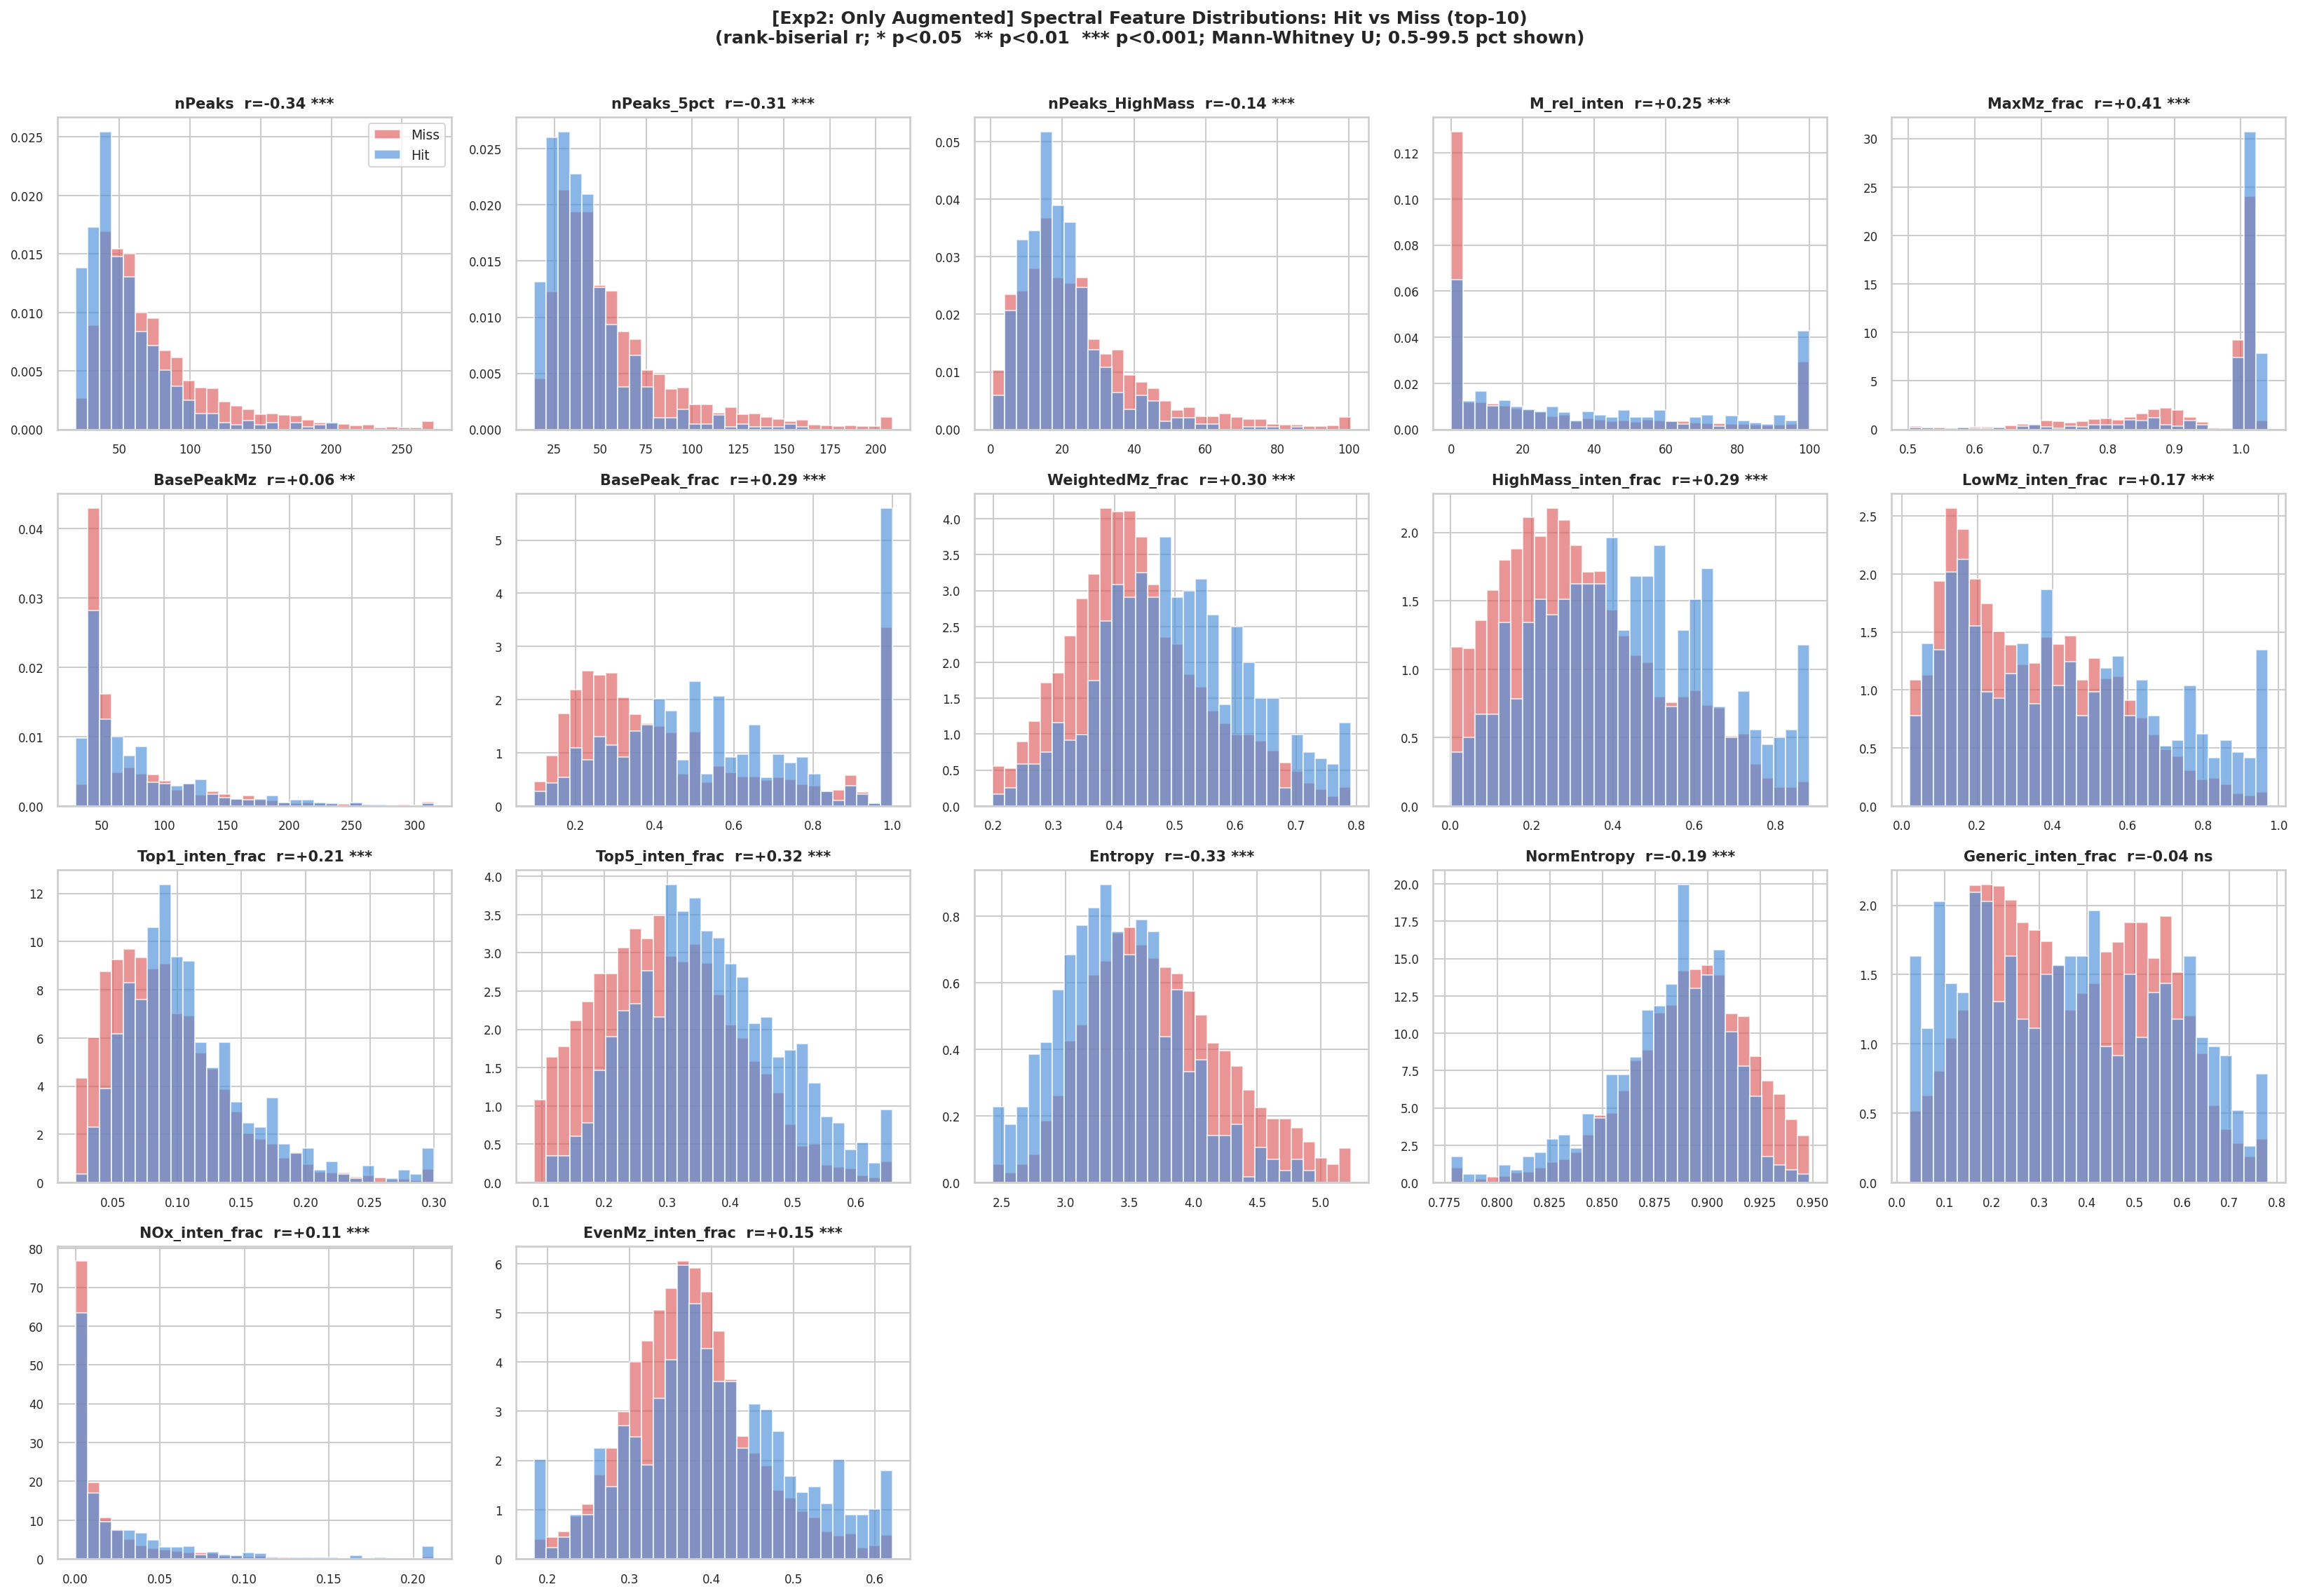


=== Exp2: Only Augmented ===


,Median (Hit),Median (Miss),Mean (Hit),Mean (Miss),r_rb,p-value
Feature,,,,,,
MaxMz_frac,1.011,1.000,0.979,0.930,0.407,0.000
nPeaks,46.000,62.000,54.310,75.878,-0.338,0.000
Entropy,3.385,3.678,3.413,3.739,-0.332,0.000
Top5_inten_frac,0.355,0.291,0.368,0.298,0.319,0.000
nPeaks_5pct,36.000,46.000,41.374,57.525,-0.308,0.000
WeightedMz_frac,0.493,0.425,0.502,0.439,0.302,0.000
HighMass_inten_frac,0.414,0.291,0.430,0.323,0.288,0.000
BasePeak_frac,0.519,0.365,0.569,0.454,0.287,0.000
M_rel_inten,28.729,9.109,39.490,26.345,0.254,0.000


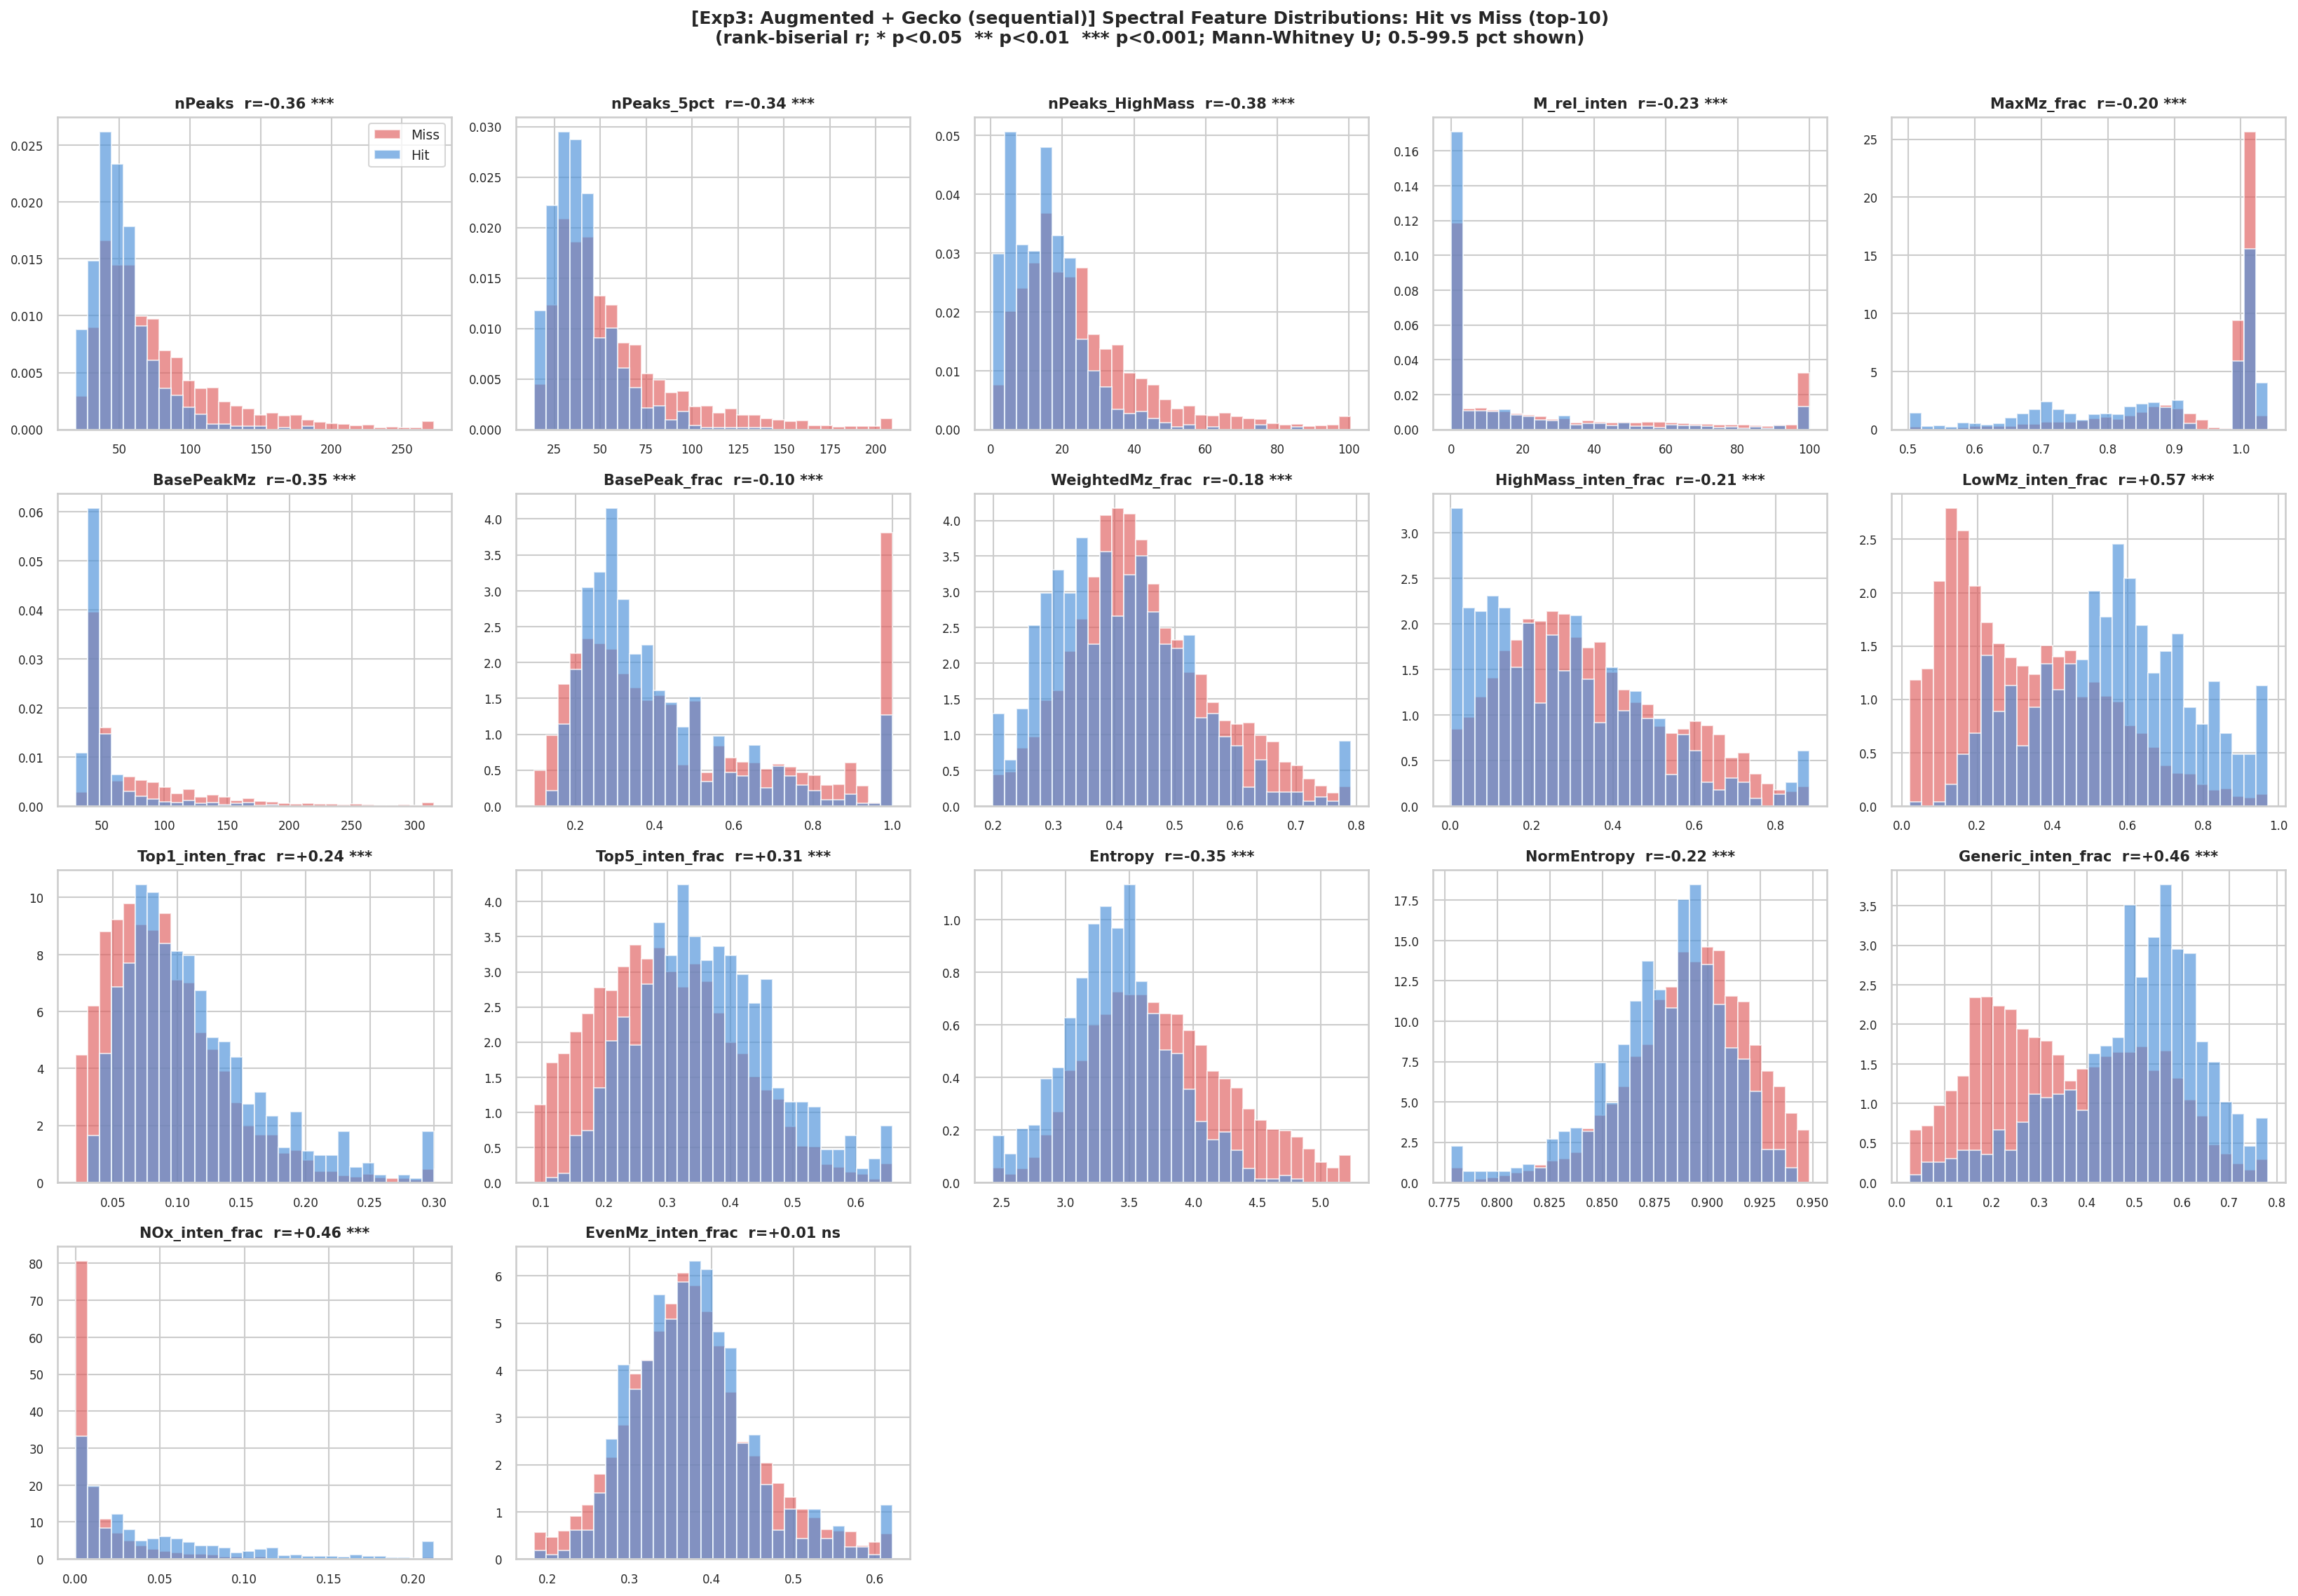


=== Exp3: Augmented + Gecko (sequential) ===


,Median (Hit),Median (Miss),Mean (Hit),Mean (Miss),r_rb,p-value
Feature,,,,,,
LowMz_inten_frac,0.564,0.286,0.556,0.325,0.571,0.000
Generic_inten_frac,0.522,0.333,0.496,0.353,0.458,0.000
NOx_inten_frac,0.027,0.005,0.049,0.015,0.456,0.000
nPeaks_HighMass,14.000,21.000,15.230,25.811,-0.379,0.000
nPeaks,47.000,63.000,51.784,76.728,-0.361,0.000
Entropy,3.397,3.692,3.408,3.748,-0.353,0.000
BasePeakMz,43.000,57.000,51.556,77.762,-0.348,0.000
nPeaks_5pct,36.000,47.000,39.760,58.129,-0.335,0.000
Top5_inten_frac,0.350,0.289,0.362,0.297,0.314,0.000


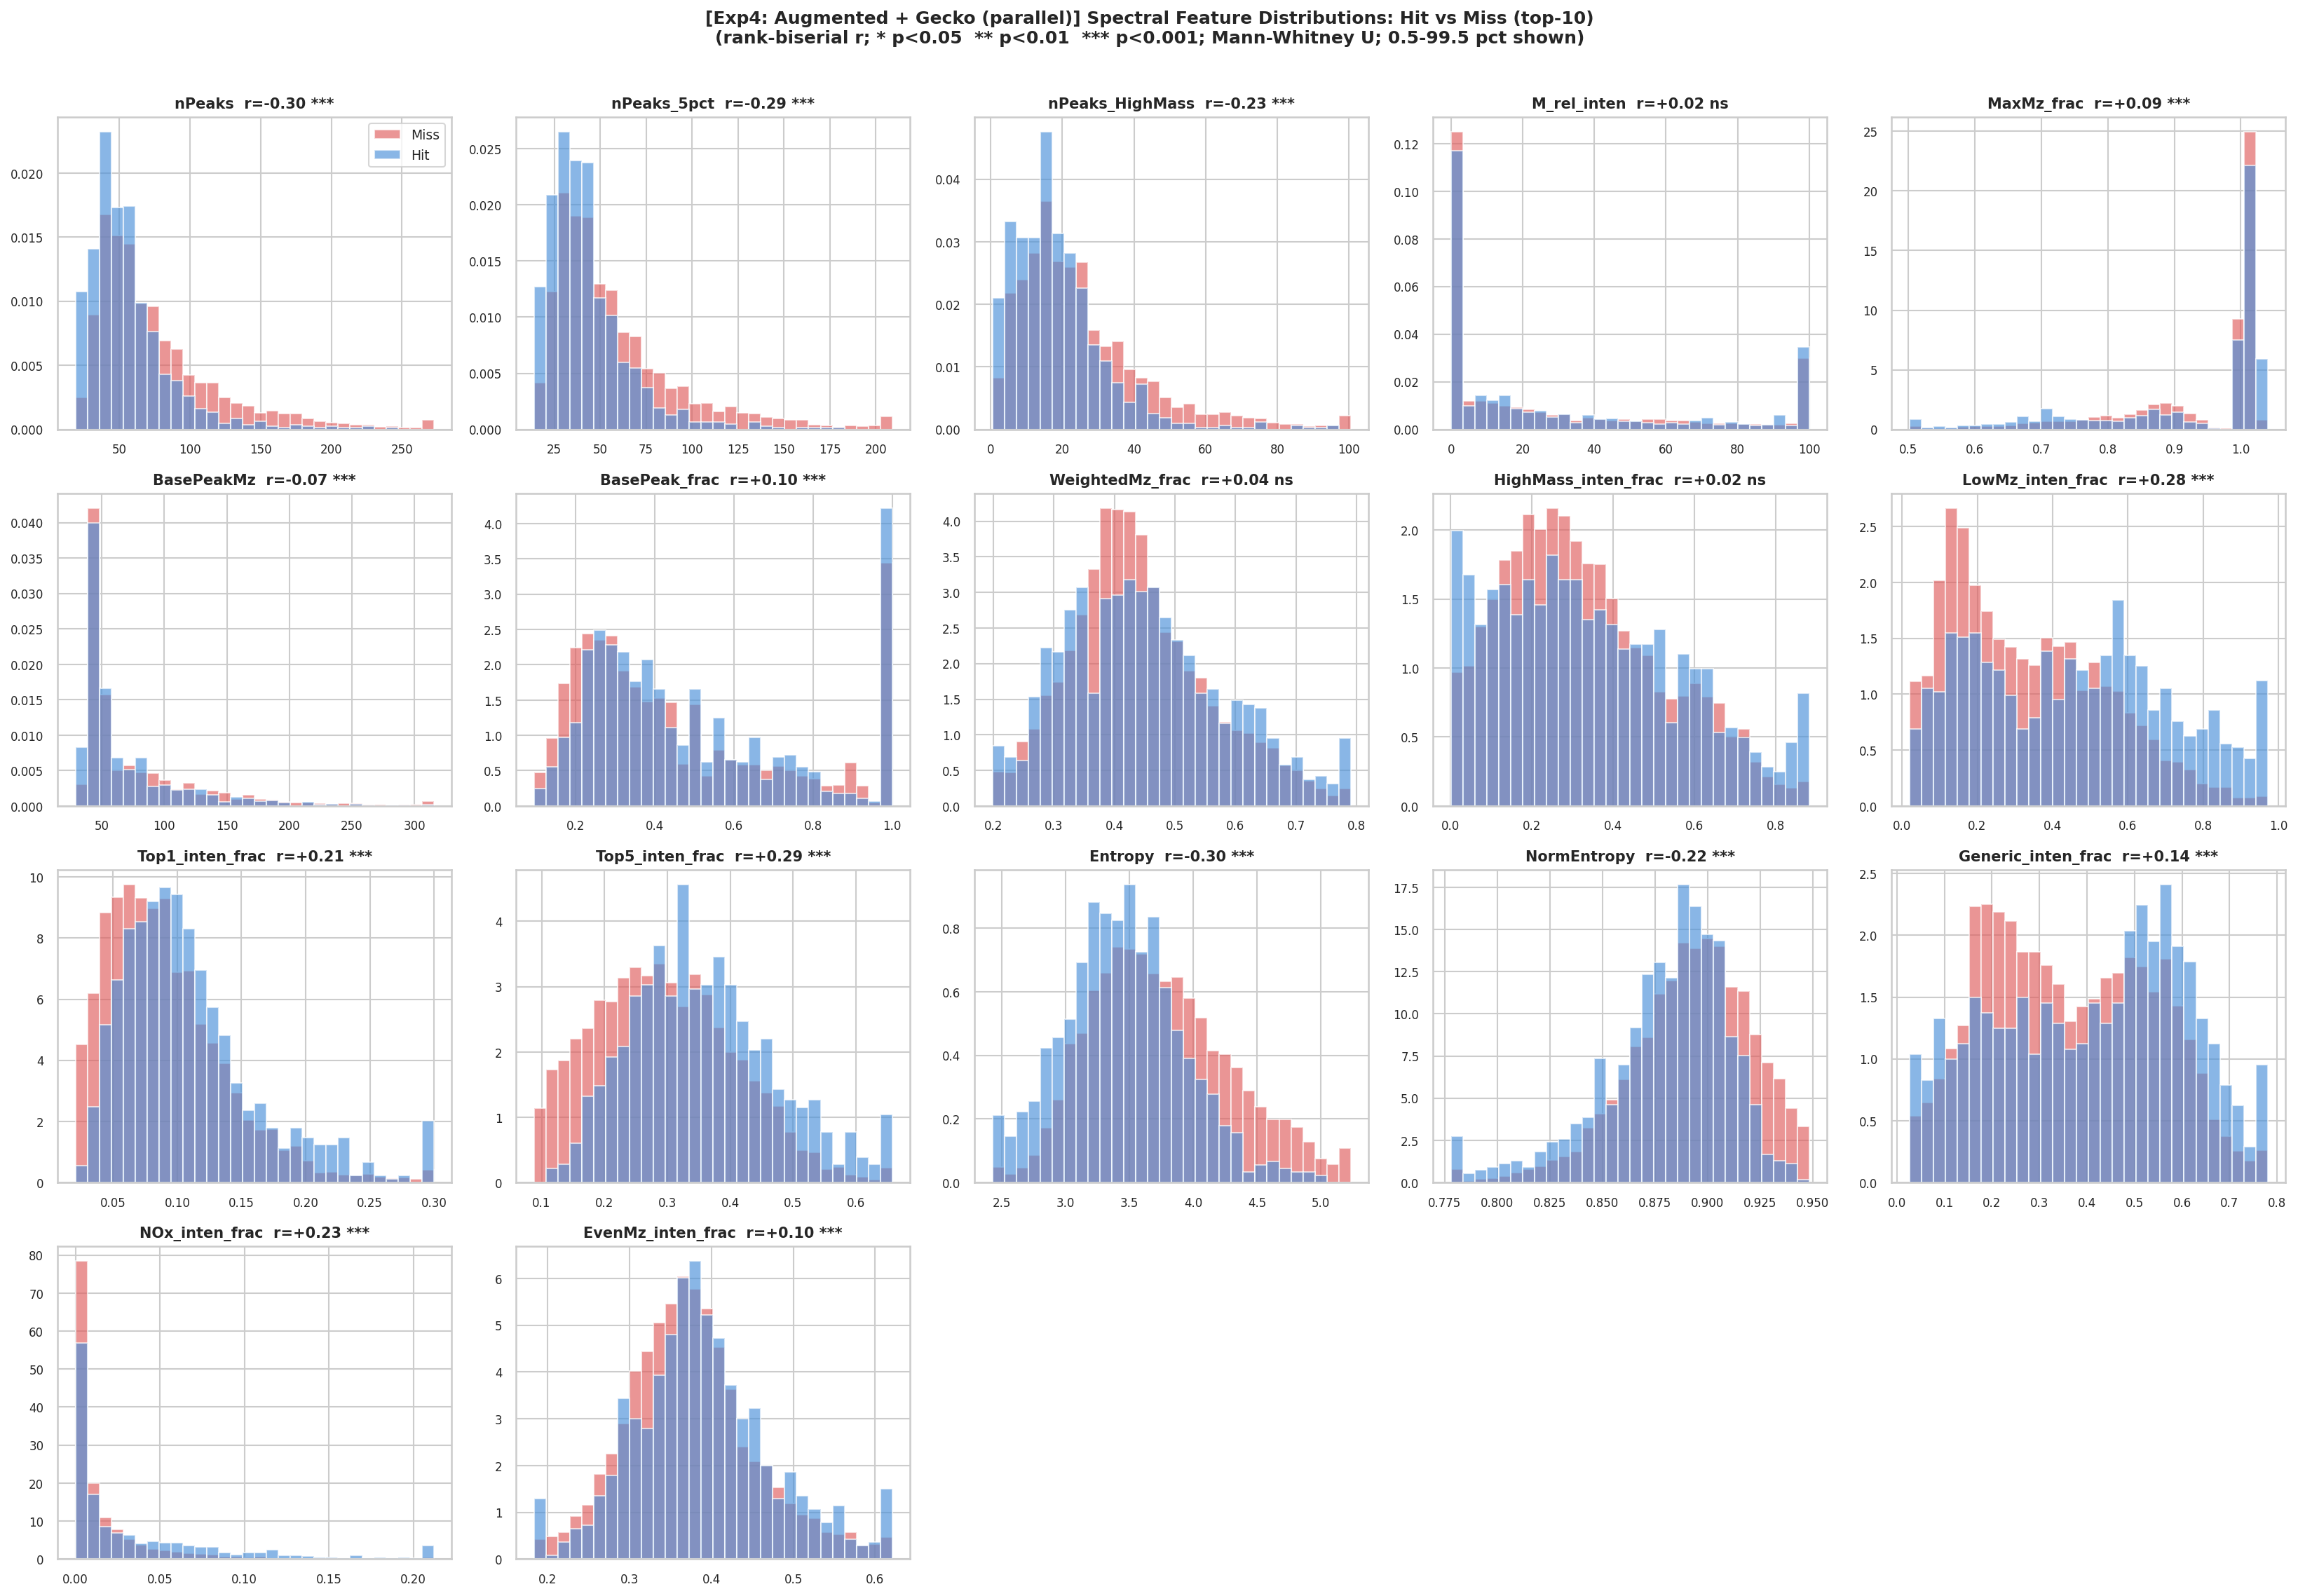


=== Exp4: Augmented + Gecko (parallel) ===


,Median (Hit),Median (Miss),Mean (Hit),Mean (Miss),r_rb,p-value
Feature,,,,,,
Entropy,3.445,3.690,3.449,3.751,-0.301,0.000
nPeaks,49.500,63.000,56.181,76.755,-0.297,0.000
Top5_inten_frac,0.345,0.288,0.359,0.296,0.290,0.000
nPeaks_5pct,37.000,47.000,42.313,58.249,-0.287,0.000
LowMz_inten_frac,0.457,0.298,0.457,0.333,0.277,0.000
nPeaks_HighMass,16.000,21.000,18.558,25.608,-0.232,0.000
NOx_inten_frac,0.013,0.005,0.037,0.016,0.225,0.000
NormEntropy,0.886,0.894,0.879,0.892,-0.221,0.000
Top1_inten_frac,0.098,0.083,0.110,0.091,0.214,0.000


In [5]:
def hit_miss_stats(adf, cols, outcome='hit_top10'):
    hit, miss = adf[adf[outcome]], adf[~adf[outcome]]
    rows = []
    for col in cols:
        h, m = hit[col].dropna(), miss[col].dropna()
        U, p = stats.mannwhitneyu(h, m, alternative='two-sided')
        rows.append({'Feature': col, 'Median (Hit)': h.median(), 'Median (Miss)': m.median(),
                     'Mean (Hit)': h.mean(), 'Mean (Miss)': m.mean(),
                     'r_rb': 2 * U / (len(h) * len(m)) - 1, 'p-value': p})
    return pd.DataFrame(rows).sort_values('r_rb', key=np.abs, ascending=False)

exp_hm_stats = {}
for exp_name, adf in exp_dfs.items():
    hit, miss = adf[adf['hit_top10']], adf[~adf['hit_top10']]
    st = hit_miss_stats(adf, SPEC_COLS).set_index('Feature')
    exp_hm_stats[exp_name] = st

    fig, axes = plt.subplots(4, 5, figsize=(22, 15), dpi=PLOT_DPI)
    axes = axes.flatten()
    for ax, col in zip(axes, SPEC_COLS):
        lo, hi = np.nanpercentile(adf[col], [0.5, 99.5])
        bins = np.linspace(lo, hi, 31) if hi > lo else 30
        ax.hist(miss[col].clip(lo, hi), bins=bins, alpha=0.65, color=MISS_COLOR, label='Miss', density=True)
        ax.hist(hit[col].clip(lo, hi),  bins=bins, alpha=0.65, color=HIT_COLOR,  label='Hit',  density=True)
        ax.set_title(f"{col}  r={st.loc[col, 'r_rb']:+.2f} {sig_stars(st.loc[col, 'p-value'])}",
                     fontsize=10, fontweight='bold')
        ax.tick_params(labelsize=8)
    for ax in axes[len(SPEC_COLS):]:
        ax.axis('off')
    axes[0].legend(fontsize=9)
    fig.suptitle(f'[{exp_name}] Spectral Feature Distributions: Hit vs Miss (top-10)\n'
                 f'(rank-biserial r; * p<0.05  ** p<0.01  *** p<0.001; Mann-Whitney U; 0.5-99.5 pct shown)',
                 y=1.01, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/hist_{exp_name.split(':')[0]}.png", bbox_inches='tight')
    plt.show()

    print(f'\n=== {exp_name} ===')
    display(st.round(3))

## 5. Cross-experiment summary
Rank-biserial effect size of each spectral feature on top-10 success, for every experiment side by side.

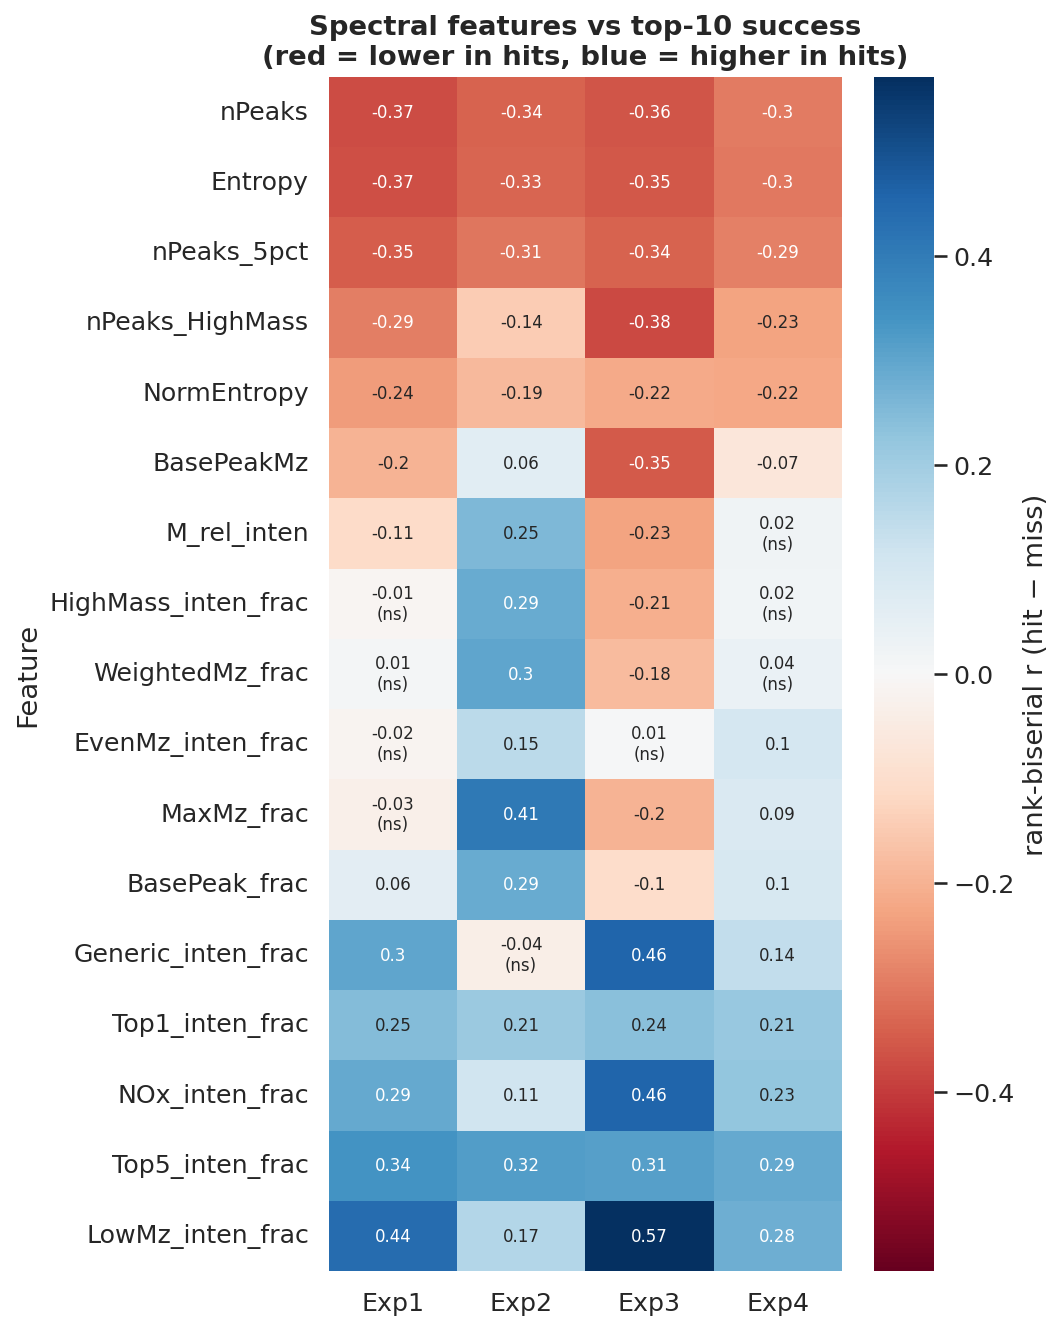

In [6]:
rb_mat = pd.DataFrame({e.split(':')[0]: s['r_rb'] for e, s in exp_hm_stats.items()}).loc[SPEC_COLS]
p_mat  = pd.DataFrame({e.split(':')[0]: s['p-value'] for e, s in exp_hm_stats.items()}).loc[SPEC_COLS]
annot  = rb_mat.round(2).astype(str) + p_mat.applymap(lambda p: '' if p < 0.05 else '\n(ns)')
order  = rb_mat.mean(axis=1).sort_values().index

fig, ax = plt.subplots(figsize=(7, 9), dpi=PLOT_DPI)
lim = np.abs(rb_mat.values).max()
sns.heatmap(rb_mat.loc[order], annot=annot.loc[order], fmt='', cmap='RdBu', center=0, vmin=-lim, vmax=lim,
            cbar_kws={'label': 'rank-biserial r (hit − miss)'}, ax=ax, annot_kws={'fontsize': 8})
ax.set_title('Spectral features vs top-10 success\n(red = lower in hits, blue = higher in hits)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/effect_size_heatmap.png', bbox_inches='tight')
plt.show()

## 6. Top-1 Tanimoto similarity: spectral feature correlations
Spearman ρ between each spectral feature and the top-1 Tanimoto similarity (graded outcome; uses all molecules, not just hits).

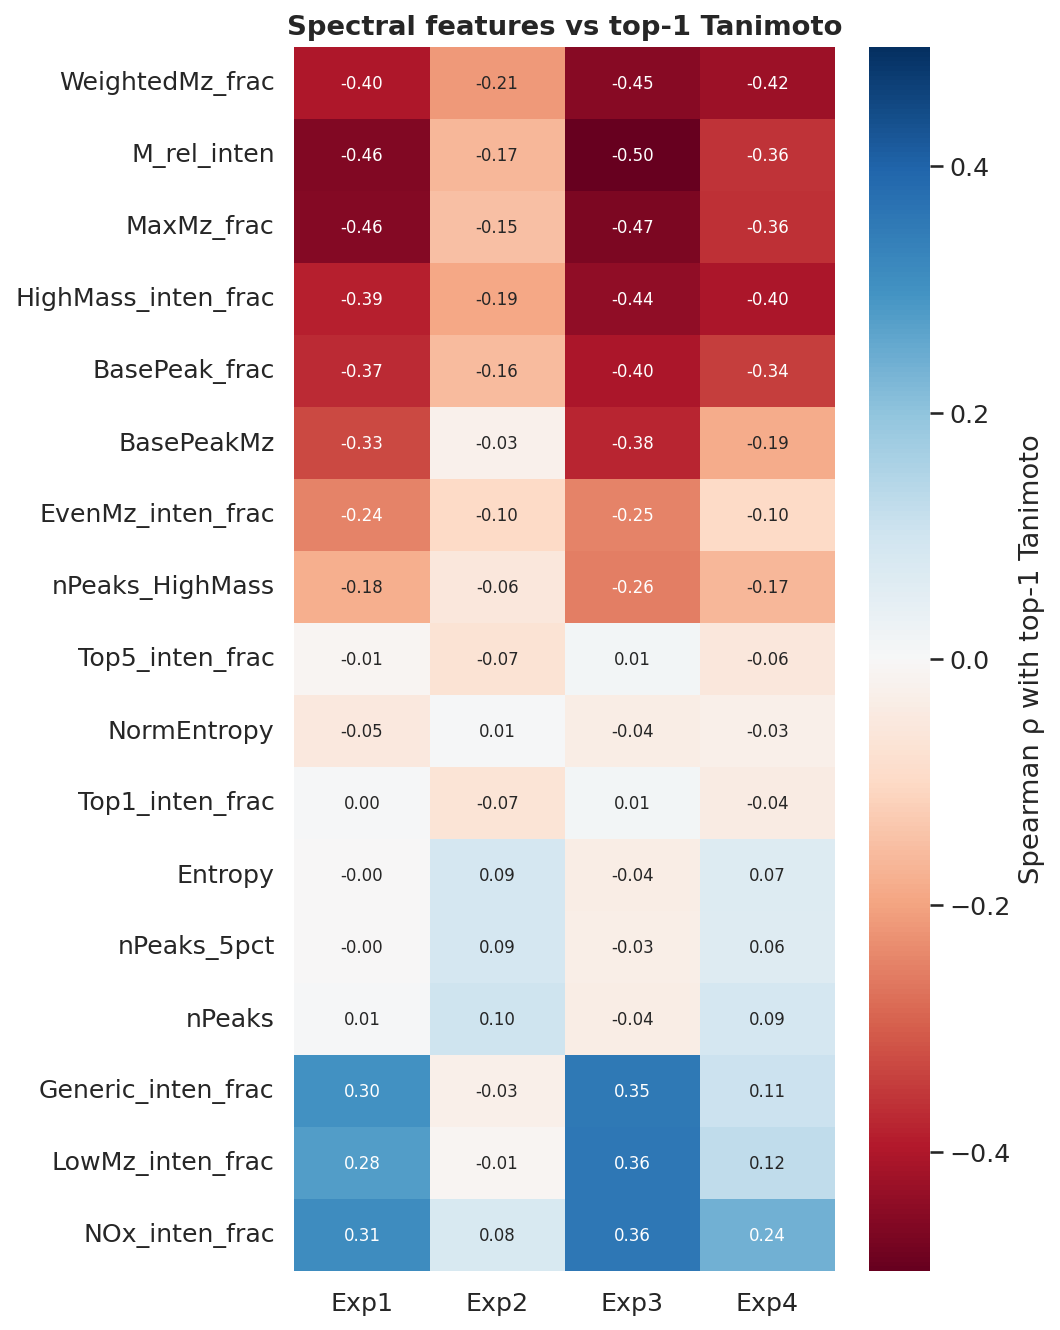

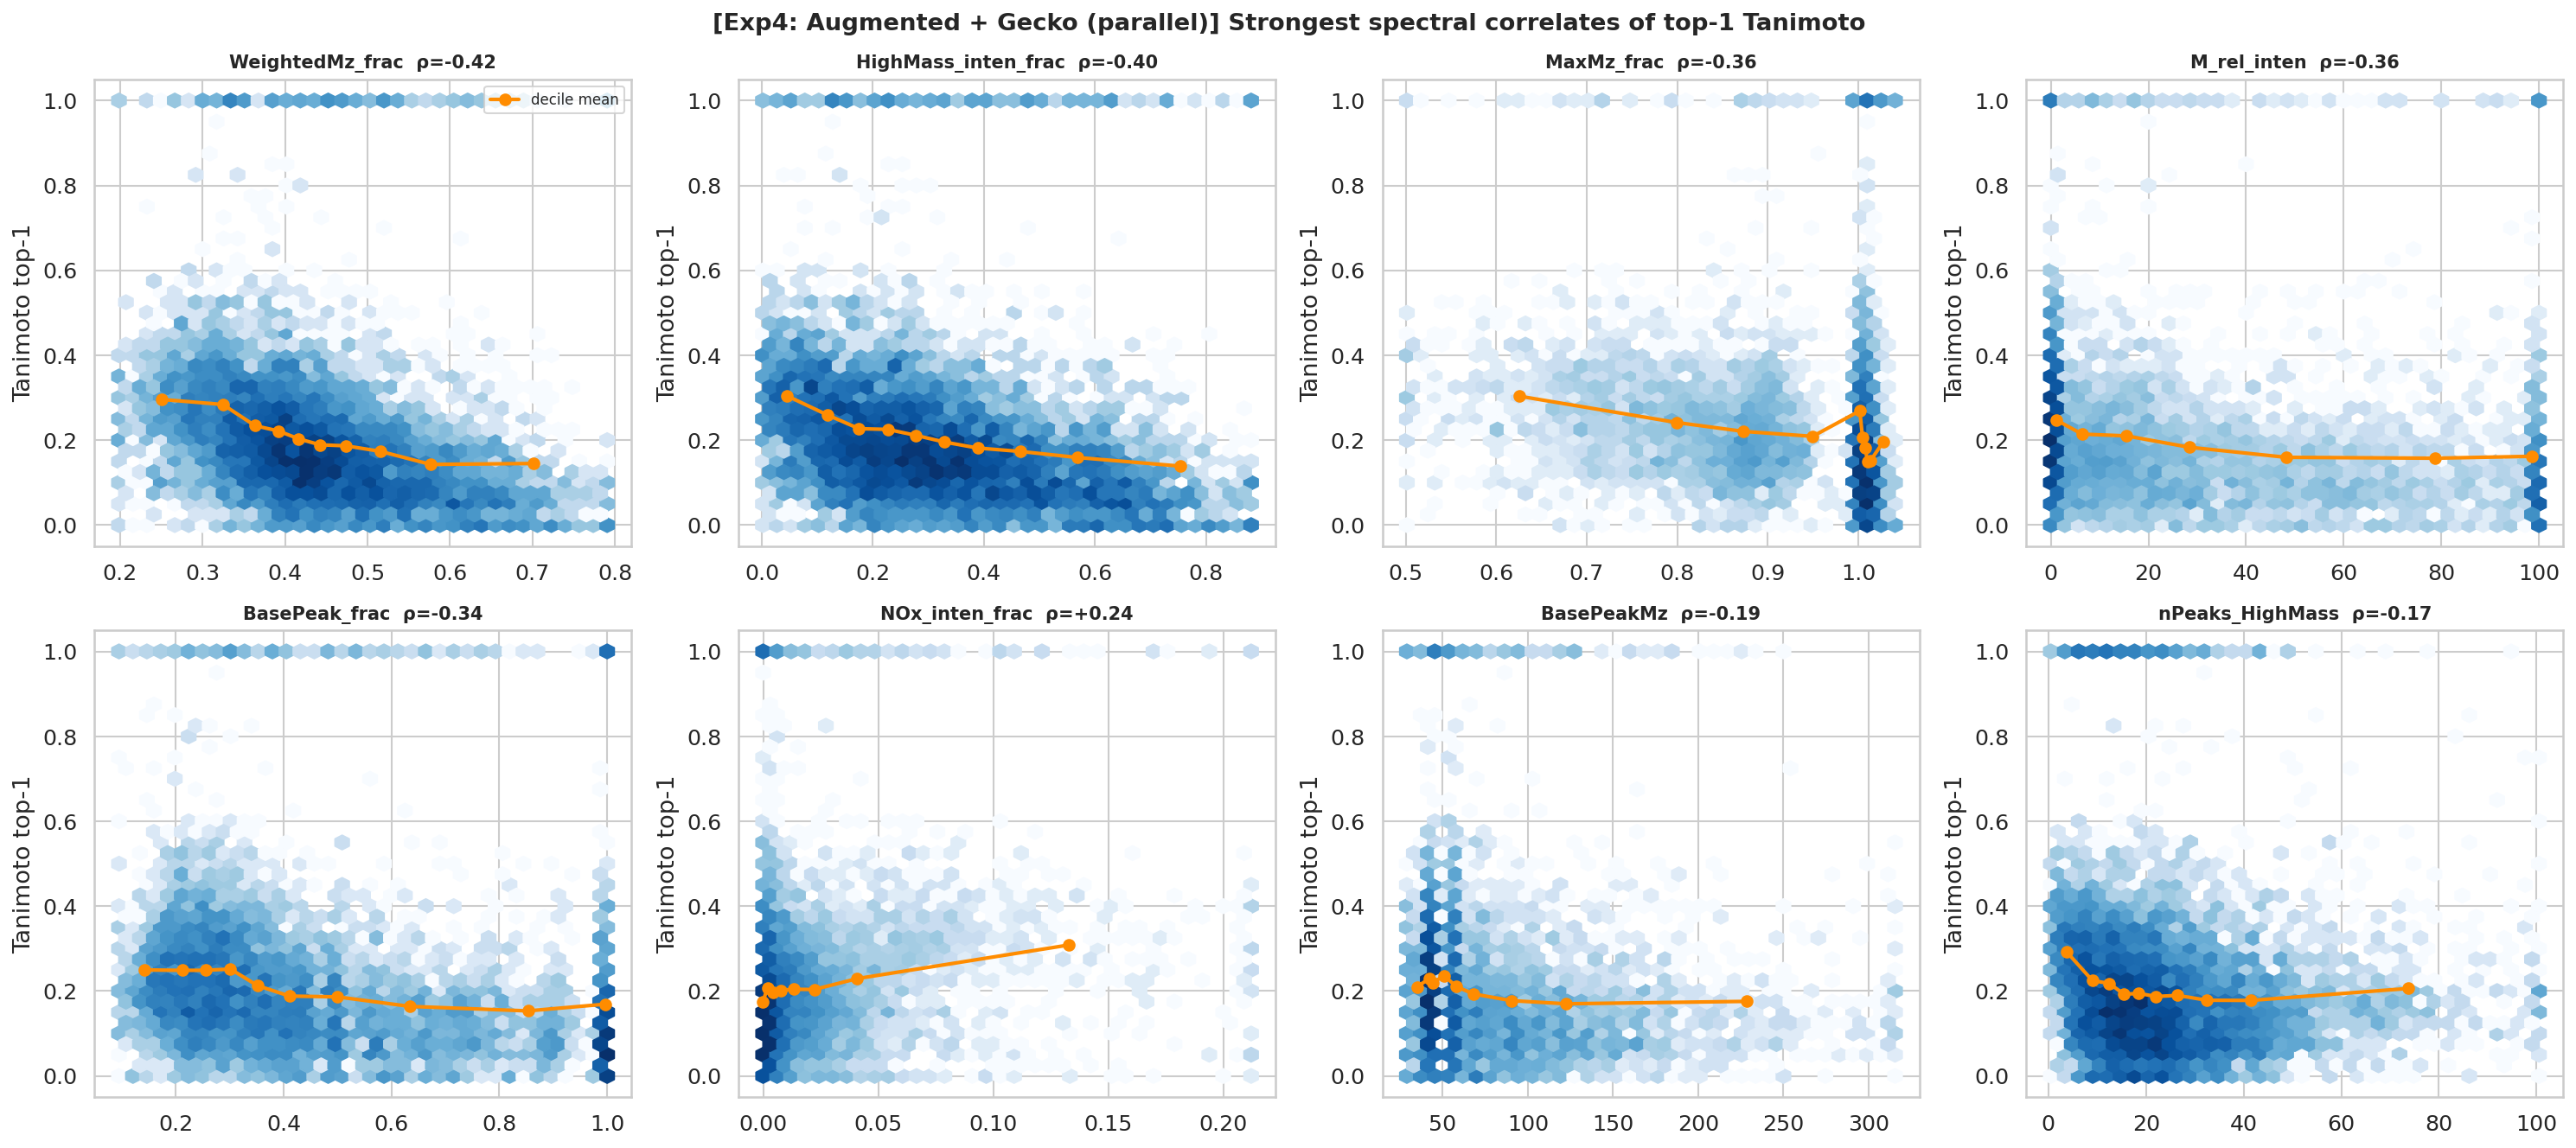

In [7]:
rho_mat = pd.DataFrame({
    e.split(':')[0]: {c: stats.spearmanr(adf[c], adf['tanimoto_top1'], nan_policy='omit')[0] for c in SPEC_COLS}
    for e, adf in exp_dfs.items()
}).loc[SPEC_COLS]
order = rho_mat.mean(axis=1).sort_values().index

fig, ax = plt.subplots(figsize=(7, 9), dpi=PLOT_DPI)
lim = np.abs(rho_mat.values).max()
sns.heatmap(rho_mat.loc[order], annot=True, fmt='.2f', cmap='RdBu', center=0, vmin=-lim, vmax=lim,
            cbar_kws={'label': 'Spearman ρ with top-1 Tanimoto'}, ax=ax, annot_kws={'fontsize': 8})
ax.set_title('Spectral features vs top-1 Tanimoto', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/tanimoto_rho_heatmap.png', bbox_inches='tight')
plt.show()

# Scatter panels for the strongest features in the best experiment
EXP_SCATTER = 'Exp4: Augmented + Gecko (parallel)'
adf = exp_dfs[EXP_SCATTER]
top_feats = rho_mat[EXP_SCATTER.split(':')[0]].abs().sort_values(ascending=False).index[:8]
fig, axes = plt.subplots(2, 4, figsize=(20, 9), dpi=PLOT_DPI)
for ax, col in zip(axes.flatten(), top_feats):
    lo, hi = np.nanpercentile(adf[col], [0.5, 99.5])
    x = adf[col].clip(lo, hi)
    ax.hexbin(x, adf['tanimoto_top1'], gridsize=35, cmap='Blues', mincnt=1, bins='log')
    # binned mean trend
    q = pd.qcut(x, 10, duplicates='drop')
    trend = adf.groupby(q, observed=True)['tanimoto_top1'].mean()
    ax.plot([iv.mid for iv in trend.index], trend.values, 'o-', color='darkorange', lw=2, label='decile mean')
    ax.set_title(f"{col}  ρ={rho_mat.loc[col, EXP_SCATTER.split(':')[0]]:+.2f}", fontsize=10, fontweight='bold')
    ax.set_ylabel('Tanimoto top-1')
axes[0, 0].legend(fontsize=8)
fig.suptitle(f'[{EXP_SCATTER}] Strongest spectral correlates of top-1 Tanimoto', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Are the spectral effects just molecular size?
The molecular notebook found size (MW, heavy atoms) to be a dominant difficulty factor, and many spectral features
scale with size. We check:
1. how spectral features correlate with molecular descriptors;
2. **partial** Spearman correlations of each spectral feature with the outcomes, controlling for MW and HeavyAtoms;
3. hit rate vs MW, stratified by molecular-ion intensity.

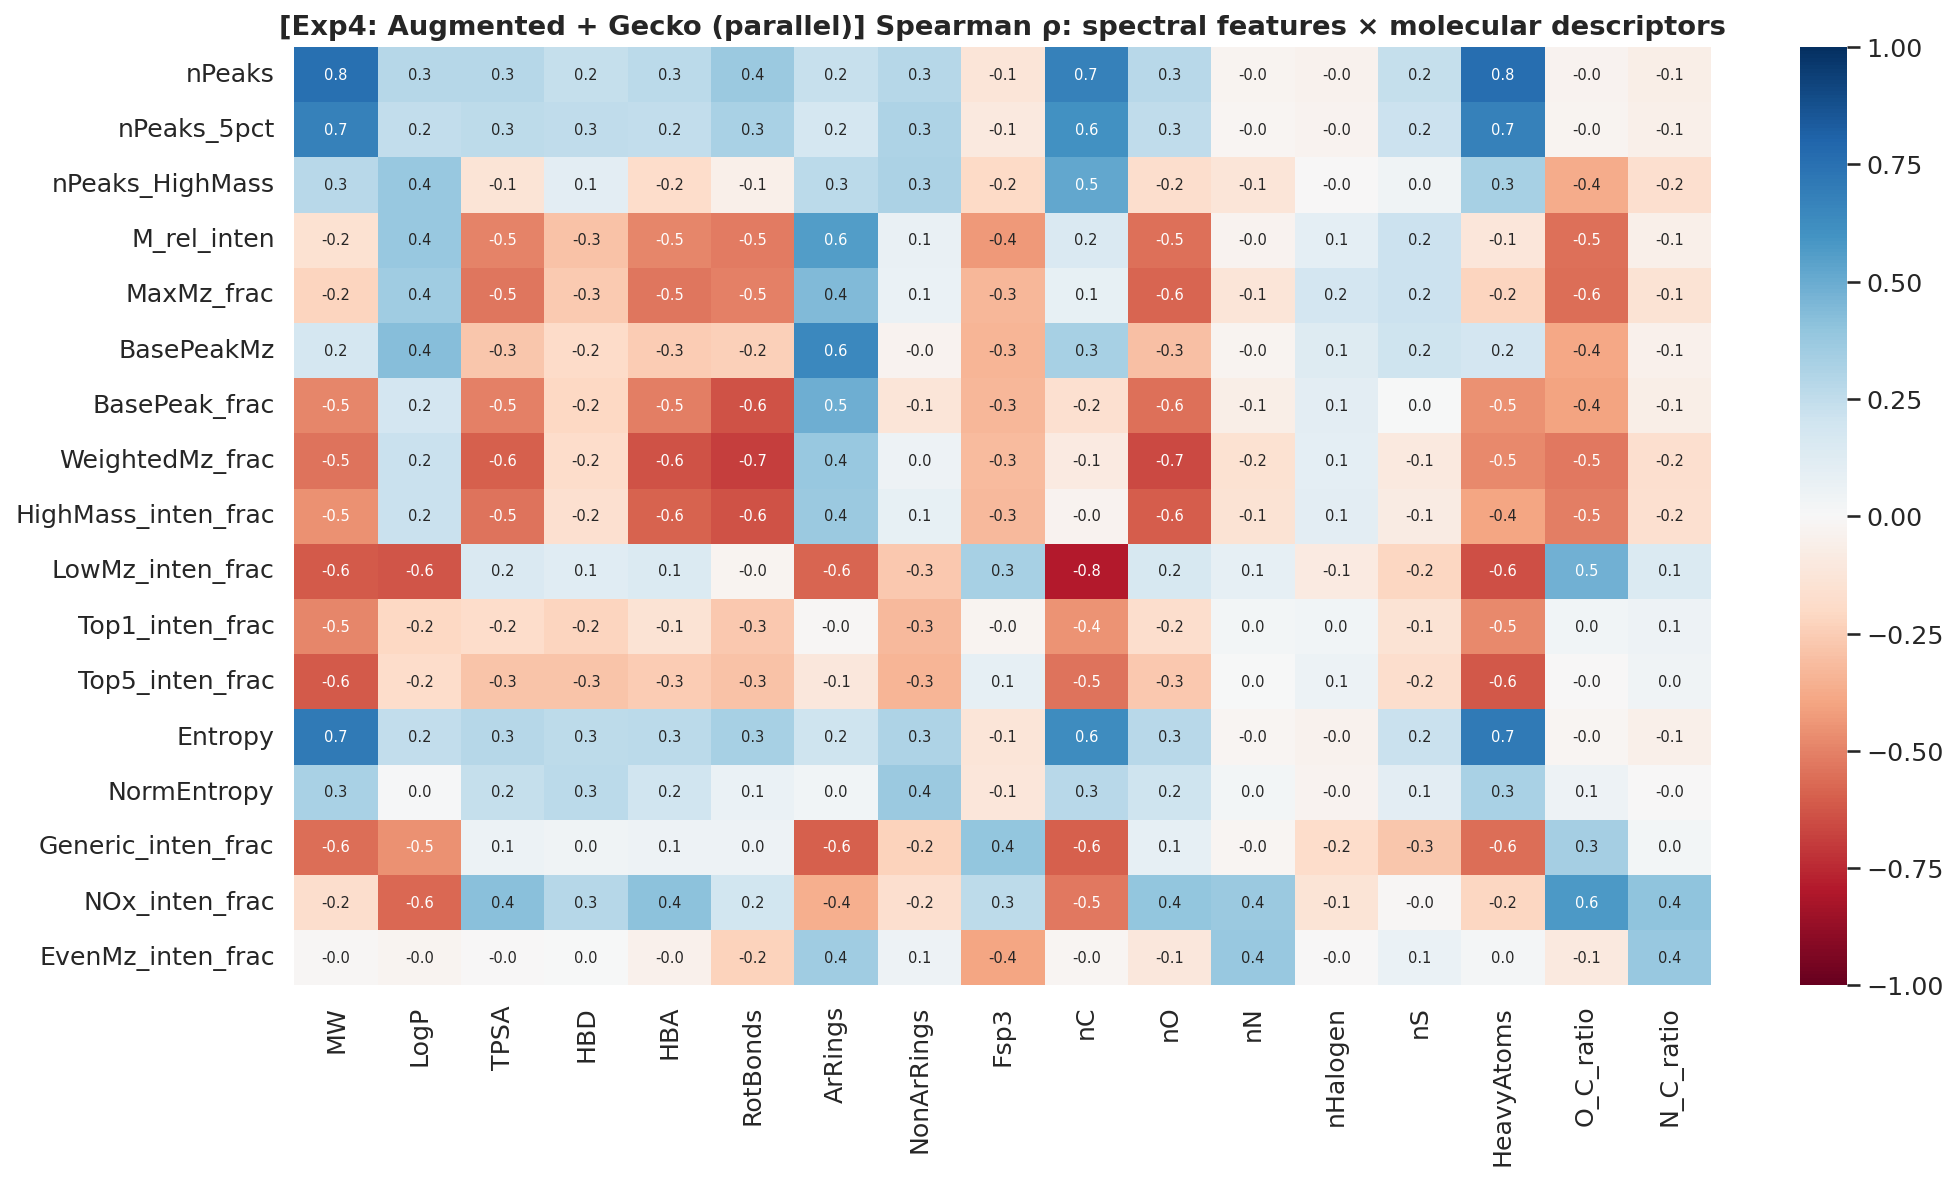

In [8]:
EXP_REF = 'Exp4: Augmented + Gecko (parallel)'
adf = exp_dfs[EXP_REF]
corr = pd.DataFrame({m: [stats.spearmanr(adf[s], adf[m])[0] for s in SPEC_COLS] for m in MOL_COLS}, index=SPEC_COLS)
fig, ax = plt.subplots(figsize=(14, 8), dpi=PLOT_DPI)
sns.heatmap(corr, annot=True, fmt='.1f', cmap='RdBu', center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'fontsize': 7})
ax.set_title(f'[{EXP_REF}] Spearman ρ: spectral features × molecular descriptors', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/spectral_vs_molecular_corr.png', bbox_inches='tight')
plt.show()

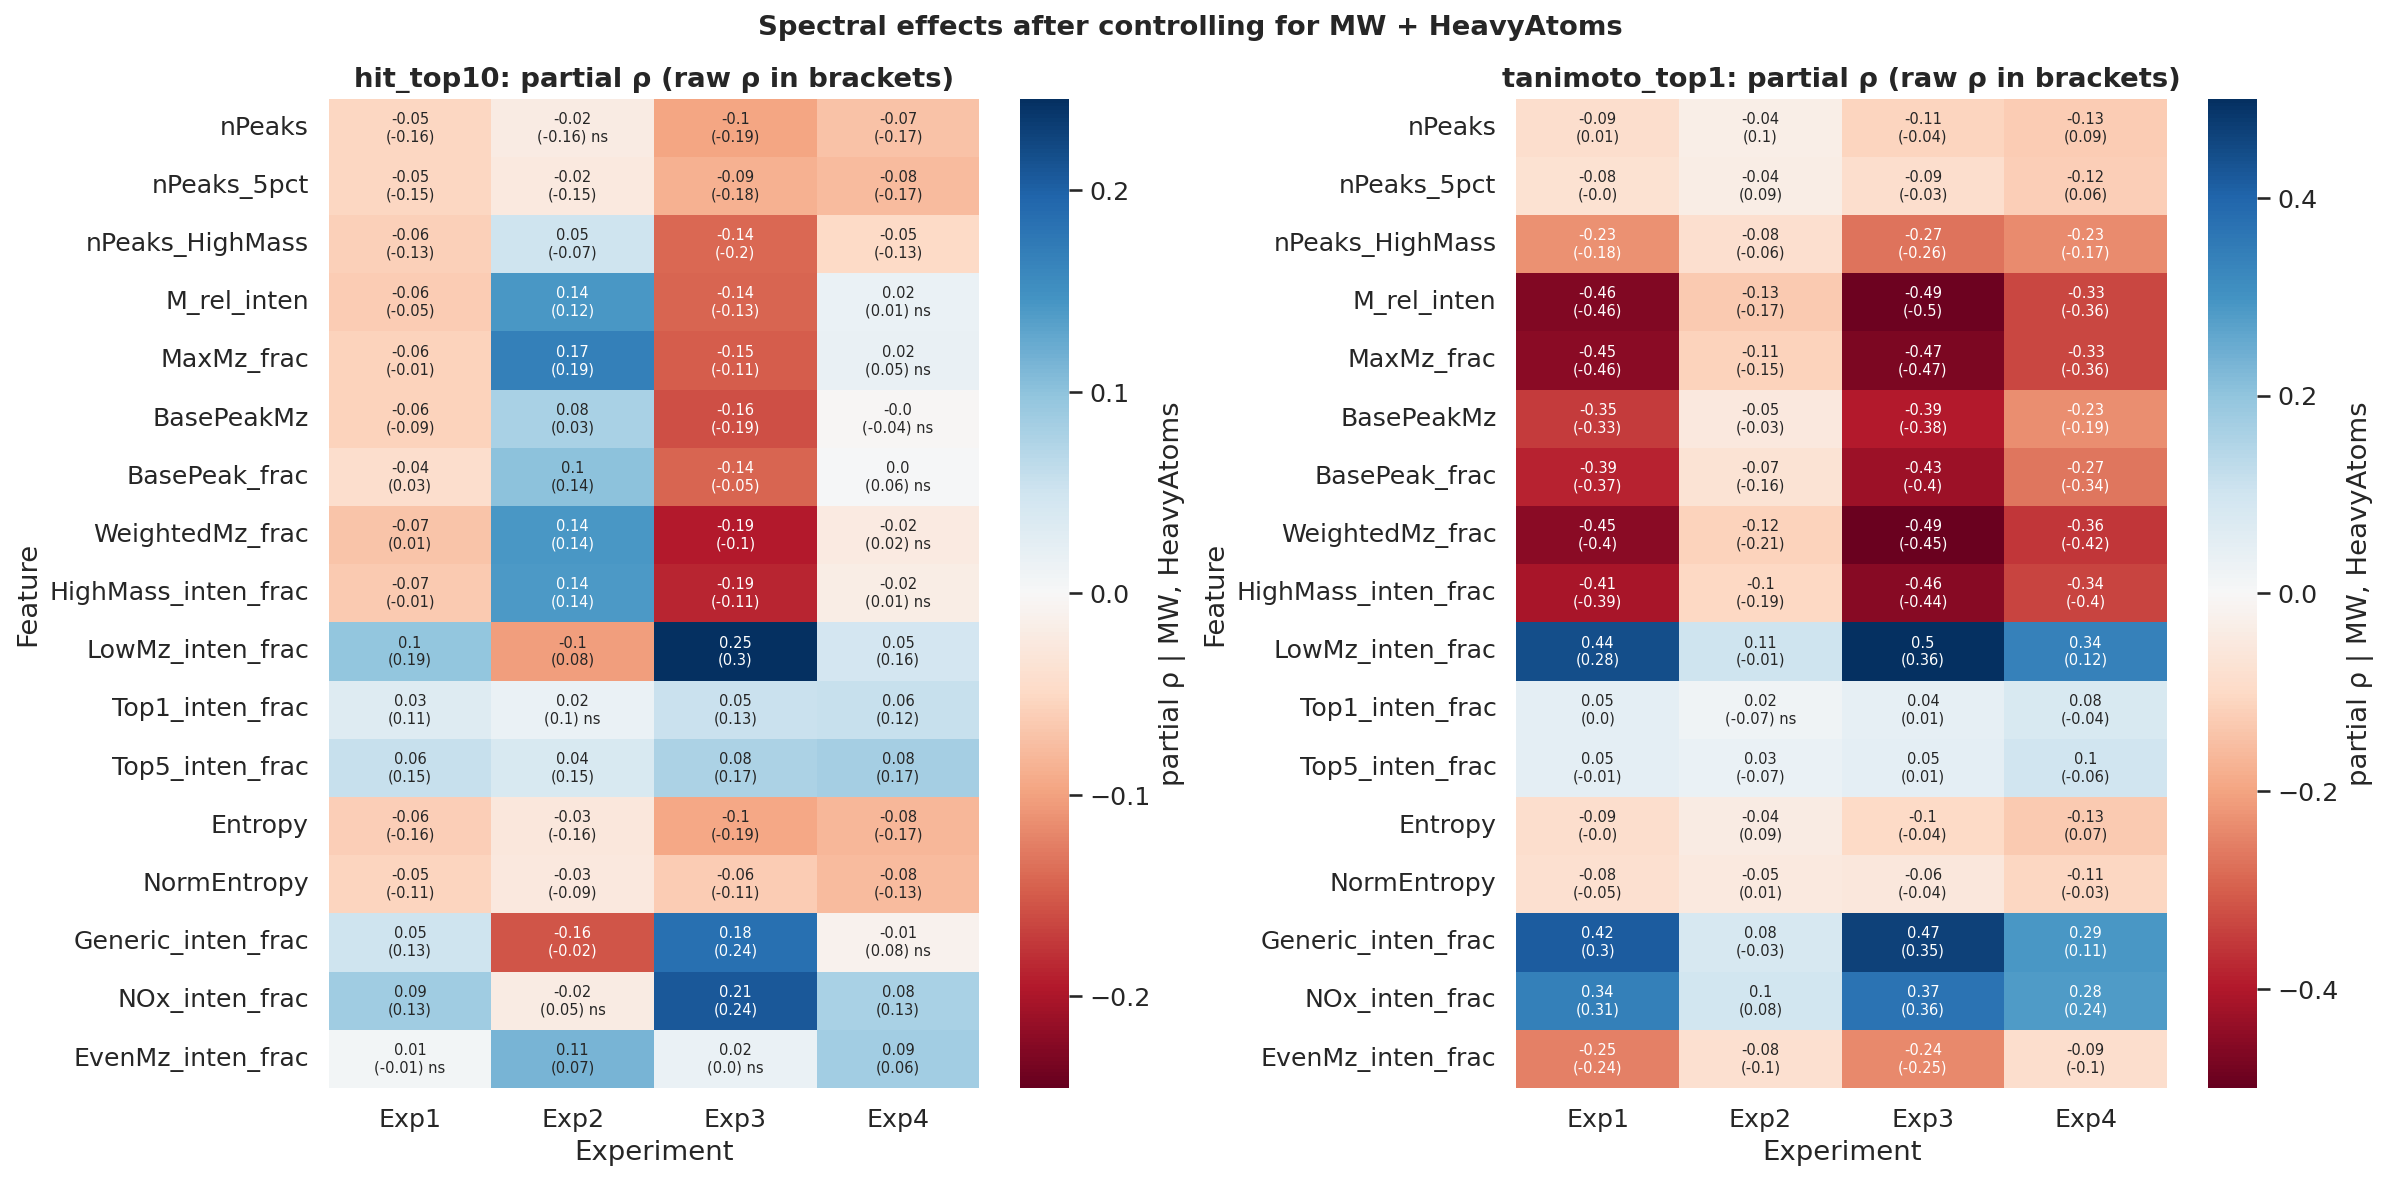

In [9]:
def partial_spearman(x, y, Z):
    '''Spearman correlation of x and y after linearly removing the ranks of the covariates Z from both.'''
    rx, ry = stats.rankdata(x), stats.rankdata(y)
    RZ = np.column_stack([np.ones(len(x))] + [stats.rankdata(z) for z in Z.T])
    res = lambda v: v - RZ @ np.linalg.lstsq(RZ, v, rcond=None)[0]
    r, p = stats.pearsonr(res(rx), res(ry))
    return r, p

COVARIATES = ['MW', 'HeavyAtoms']
part_rows = []
for exp_name, adf in exp_dfs.items():
    Z = adf[COVARIATES].values
    for col in SPEC_COLS:
        for outcome in ['hit_top10', 'tanimoto_top1']:
            y = adf[outcome].astype(float).values
            raw = stats.spearmanr(adf[col], y)[0]
            pr, pp = partial_spearman(adf[col].values, y, Z)
            part_rows.append({'Experiment': exp_name.split(':')[0], 'Feature': col, 'Outcome': outcome,
                              'rho_raw': raw, 'rho_partial': pr, 'p_partial': pp})
part_df = pd.DataFrame(part_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), dpi=PLOT_DPI)
for ax, outcome in zip(axes, ['hit_top10', 'tanimoto_top1']):
    d = part_df[part_df.Outcome == outcome]
    raw = d.pivot(index='Feature', columns='Experiment', values='rho_raw').loc[SPEC_COLS]
    par = d.pivot(index='Feature', columns='Experiment', values='rho_partial').loc[SPEC_COLS]
    pv  = d.pivot(index='Feature', columns='Experiment', values='p_partial').loc[SPEC_COLS]
    annot = par.round(2).astype(str) + '\n(' + raw.round(2).astype(str) + ')' + pv.applymap(lambda p: '' if p < 0.05 else ' ns')
    lim = max(np.abs(par.values).max(), 0.05)
    sns.heatmap(par, annot=annot, fmt='', cmap='RdBu', center=0, vmin=-lim, vmax=lim, ax=ax, annot_kws={'fontsize': 7},
                cbar_kws={'label': f'partial ρ | {", ".join(COVARIATES)}'})
    ax.set_title(f'{outcome}: partial ρ (raw ρ in brackets)', fontweight='bold')
plt.suptitle(f'Spectral effects after controlling for {" + ".join(COVARIATES)}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/partial_correlations.png', bbox_inches='tight')
plt.show()

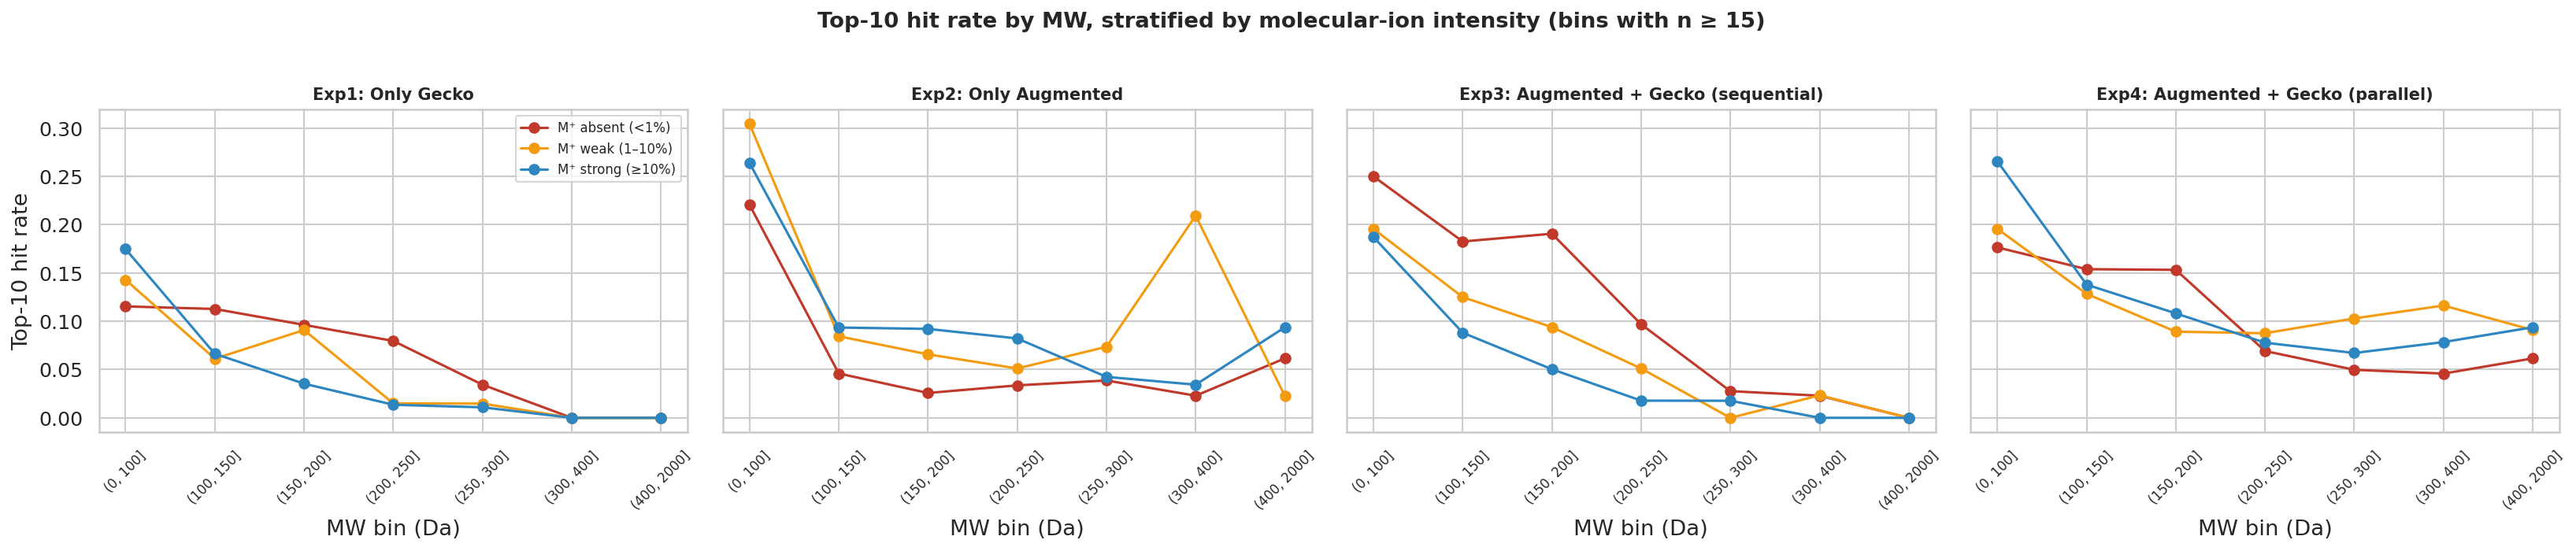

Exp1: Only Gecko


,n,hit10,tanimoto,MW
Mion,,,,
M⁺ absent (<1%),2314,0.087,0.240,172.146
M⁺ weak (1–10%),755,0.053,0.182,173.032
M⁺ strong (≥10%),3565,0.058,0.129,152.120


Exp2: Only Augmented


,n,hit10,tanimoto,MW
Mion,,,,
M⁺ absent (<1%),2852,0.041,0.165,165.027
M⁺ weak (1–10%),847,0.089,0.160,167.911
M⁺ strong (≥10%),3801,0.110,0.156,150.071


Exp3: Augmented + Gecko (sequential)


,n,hit10,tanimoto,MW
Mion,,,,
M⁺ absent (<1%),2852,0.150,0.253,165.027
M⁺ weak (1–10%),847,0.087,0.187,167.911
M⁺ strong (≥10%),3801,0.074,0.131,150.071


Exp4: Augmented + Gecko (parallel)


,n,hit10,tanimoto,MW
Mion,,,,
M⁺ absent (<1%),2852,0.126,0.251,165.027
M⁺ weak (1–10%),847,0.111,0.210,167.911
M⁺ strong (≥10%),3801,0.133,0.175,150.071


In [10]:
# Hit rate vs MW, stratified by molecular-ion intensity
M_BINS   = [-0.01, 1, 10, 100.01]
M_LABELS = ['M⁺ absent (<1%)', 'M⁺ weak (1–10%)', 'M⁺ strong (≥10%)']
MW_BINS  = [0, 100, 150, 200, 250, 300, 400, 2000]

fig, axes = plt.subplots(1, len(exp_dfs), figsize=(5.5 * len(exp_dfs), 4.5), dpi=PLOT_DPI, sharey=True)
for ax, (exp_name, adf) in zip(axes, exp_dfs.items()):
    d = adf.assign(Mion=pd.cut(adf.M_rel_inten, M_BINS, labels=M_LABELS),
                   MWbin=pd.cut(adf.MW, MW_BINS))
    g = d.groupby(['Mion', 'MWbin'], observed=True)['hit_top10'].agg(['mean', 'count']).reset_index()
    for lab, c in zip(M_LABELS, ['#c0392b', '#f39c12', '#2e86c1']):
        s = g[(g.Mion == lab) & (g['count'] >= 15)]
        ax.plot(s.MWbin.astype(str), s['mean'], 'o-', color=c, label=lab)
    ax.set_title(exp_name, fontsize=10, fontweight='bold')
    ax.set_xlabel('MW bin (Da)')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
axes[0].set_ylabel('Top-10 hit rate')
axes[0].legend(fontsize=8)
plt.suptitle('Top-10 hit rate by MW, stratified by molecular-ion intensity (bins with n ≥ 15)', fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/hit_rate_MW_by_Mion.png', bbox_inches='tight')
plt.show()

for exp_name, adf in exp_dfs.items():
    d = adf.assign(Mion=pd.cut(adf.M_rel_inten, M_BINS, labels=M_LABELS))
    print(exp_name)
    display(d.groupby('Mion', observed=True).agg(n=('hit_top10', 'size'), hit10=('hit_top10', 'mean'),
                                                 tanimoto=('tanimoto_top1', 'mean'), MW=('MW', 'median')).round(3))

## 8. Predictive value: molecular vs spectral vs combined
How much of per-molecule difficulty can be predicted from (a) molecular descriptors, (b) spectral summary features,
(c) both? Gradient-boosted trees, 5-fold CV. Metrics: ROC-AUC / average precision for top-10 hit, Spearman ρ between
out-of-fold predictions and true top-1 Tanimoto. If (c) clearly beats (a), the spectrum carries difficulty
information that the structure descriptors don't.

,Experiment,Features,ROC-AUC (hit10),AP (hit10),AP baseline,Spearman (tanimoto)
0,Exp1,molecular,0.888,0.390,0.067,0.704
1,Exp1,spectral,0.805,0.249,0.067,0.582
2,Exp1,combined,0.870,0.359,0.067,0.700
3,Exp2,molecular,0.901,0.542,0.081,0.386
4,Exp2,spectral,0.843,0.410,0.081,0.268
5,Exp2,combined,0.900,0.540,0.081,0.360
6,Exp3,molecular,0.891,0.497,0.104,0.727
7,Exp3,spectral,0.824,0.353,0.104,0.632
8,Exp3,combined,0.886,0.473,0.104,0.726
9,Exp4,molecular,0.853,0.508,0.128,0.595


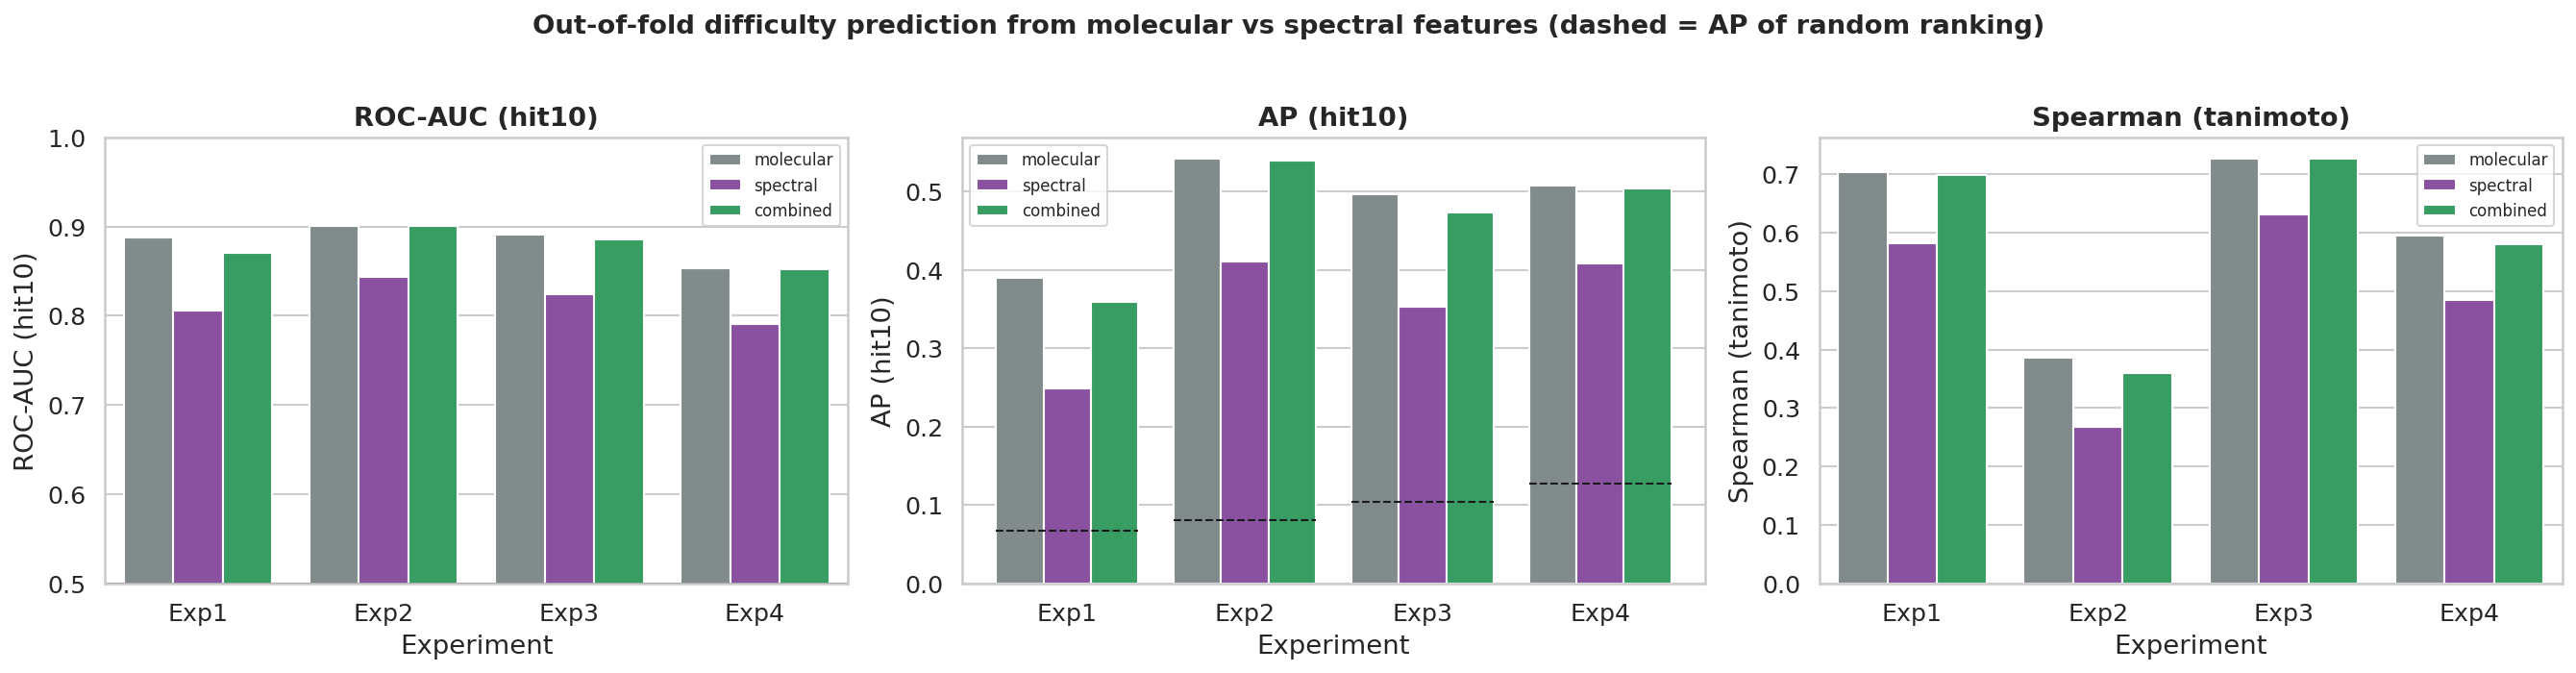

In [11]:
FEATURE_SETS = {'molecular': MOL_COLS, 'spectral': SPEC_COLS, 'combined': MOL_COLS + SPEC_COLS}

ml_rows = []
for exp_name, adf in exp_dfs.items():
    y_hit = adf['hit_top10'].astype(int).values
    y_tan = adf['tanimoto_top1'].values
    for fs_name, cols in FEATURE_SETS.items():
        X = adf[cols].values
        clf = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                                             l2_regularization=1.0, random_state=42)
        prob = cross_val_predict(clf, X, y_hit, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                 method='predict_proba')[:, 1]
        reg = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                                            l2_regularization=1.0, random_state=42)
        pred = cross_val_predict(reg, X, y_tan, cv=KFold(5, shuffle=True, random_state=42))
        ml_rows.append({'Experiment': exp_name.split(':')[0], 'Features': fs_name,
                        'ROC-AUC (hit10)': roc_auc_score(y_hit, prob),
                        'AP (hit10)': average_precision_score(y_hit, prob),
                        'AP baseline': y_hit.mean(),
                        'Spearman (tanimoto)': stats.spearmanr(pred, y_tan)[0]})
ml_df = pd.DataFrame(ml_rows)
display(ml_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), dpi=PLOT_DPI)
for ax, metric in zip(axes, ['ROC-AUC (hit10)', 'AP (hit10)', 'Spearman (tanimoto)']):
    sns.barplot(ml_df, x='Experiment', y=metric, hue='Features', ax=ax,
                palette={'molecular': '#7f8c8d', 'spectral': '#8e44ad', 'combined': '#27ae60'})
    if metric == 'ROC-AUC (hit10)':
        ax.set_ylim(0.5, 1); ax.axhline(0.5, color='k', lw=0.8)
    if metric == 'AP (hit10)':
        for i, e in enumerate(ml_df.Experiment.unique()):
            b = ml_df[ml_df.Experiment == e]['AP baseline'].iloc[0]
            ax.hlines(b, i - 0.4, i + 0.4, color='k', ls='--', lw=1)
    ax.set_title(metric, fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('Out-of-fold difficulty prediction from molecular vs spectral features (dashed = AP of random ranking)',
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/difficulty_prediction.png', bbox_inches='tight')
plt.show()

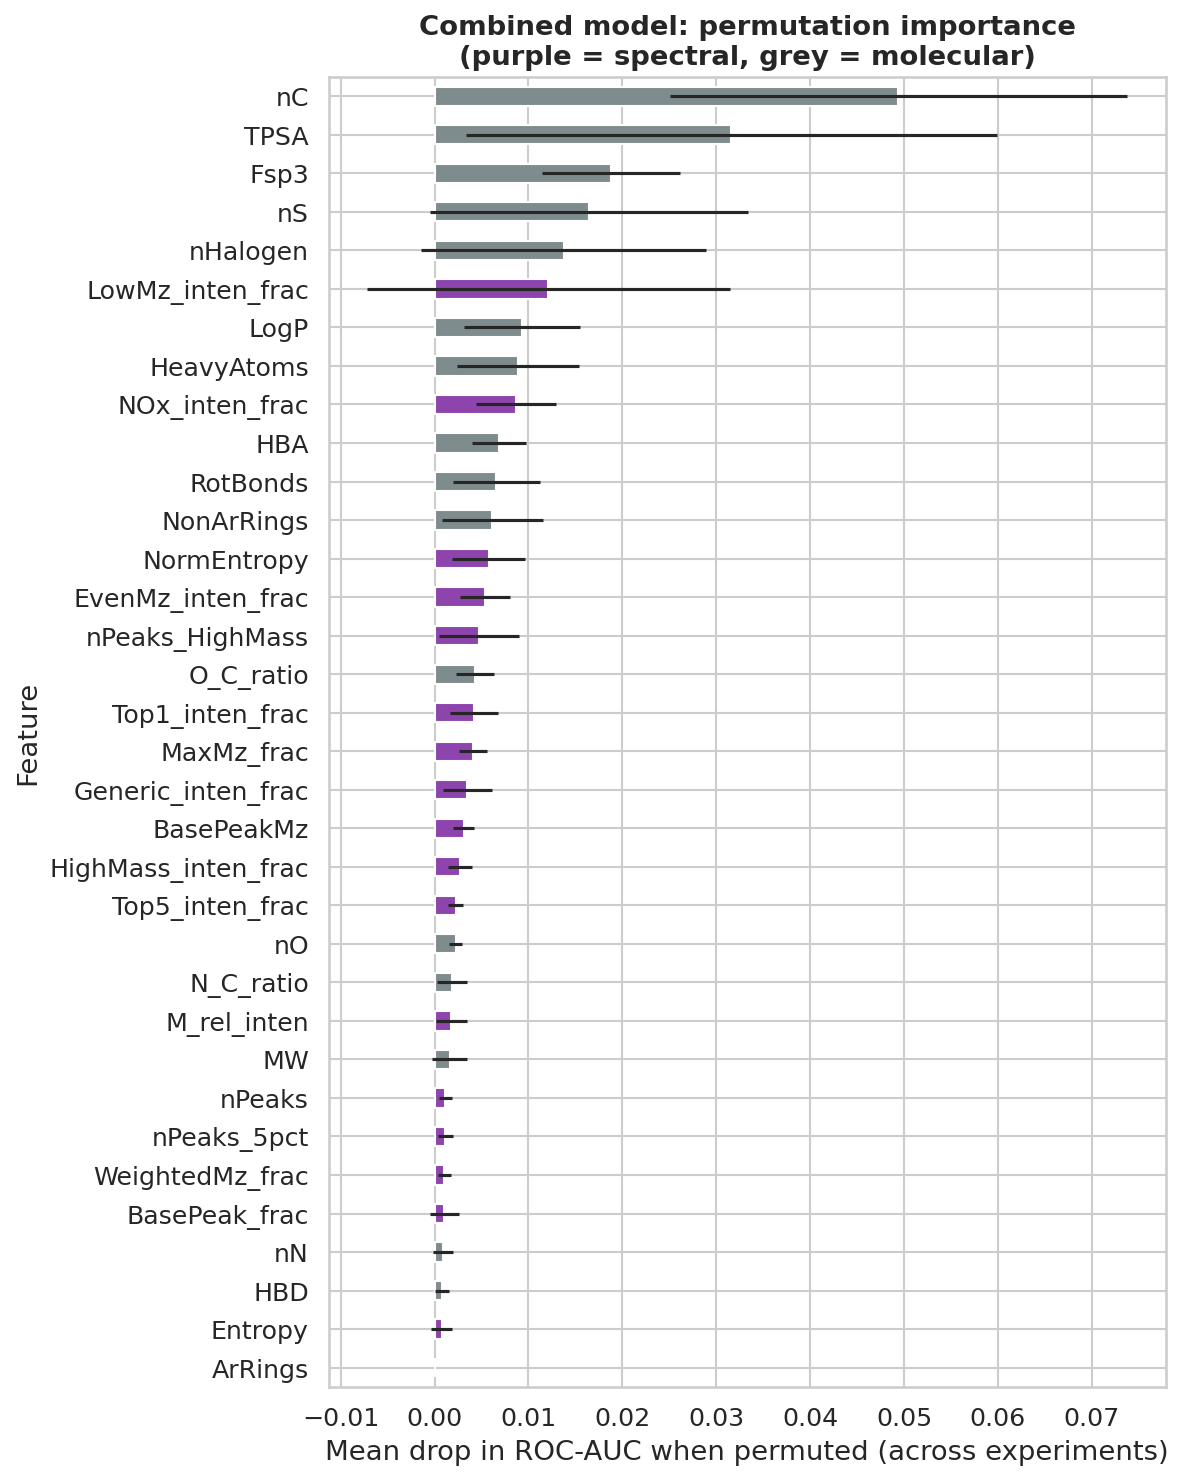

Experiment,Exp1,Exp2,Exp3,Exp4
Feature,,,,
nC,0.0725,0.0154,0.0591,0.0506
TPSA,0.0272,0.0074,0.0722,0.0196
Fsp3,0.0093,0.0175,0.0219,0.0265
nS,0.0343,0.0036,0.0275,0.0004
nHalogen,0.0007,0.0308,0.0013,0.0222
LowMz_inten_frac,0.0019,0.0022,0.0411,0.0032
LogP,0.0148,0.0013,0.0133,0.0078
HeavyAtoms,0.0112,0.0159,0.0082,0.0003
NOx_inten_frac,0.0110,0.0092,0.0025,0.0121


In [12]:
# Which features carry the signal in the combined model? (permutation importance on held-out folds, ROC-AUC)
imp_rows = []
for exp_name, adf in exp_dfs.items():
    cols = FEATURE_SETS['combined']
    X, y = adf[cols].values, adf['hit_top10'].astype(int).values
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=0).split(X, y):
        clf = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                                             l2_regularization=1.0, random_state=42).fit(X[tr], y[tr])
        pi = permutation_importance(clf, X[te], y[te], scoring='roc_auc', n_repeats=5, random_state=0)
        imp_rows += [{'Experiment': exp_name.split(':')[0], 'Feature': c, 'importance': v}
                     for c, v in zip(cols, pi.importances_mean)]
imp = pd.DataFrame(imp_rows).groupby(['Experiment', 'Feature'])['importance'].mean().unstack(0)
imp = imp.loc[imp.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8, 10), dpi=PLOT_DPI)
colors = ['#8e44ad' if f in SPEC_COLS else '#7f8c8d' for f in imp.index]
imp.mean(axis=1).plot.barh(ax=ax, color=colors, xerr=imp.std(axis=1))
ax.invert_yaxis()
ax.set_xlabel('Mean drop in ROC-AUC when permuted (across experiments)')
ax.set_title('Combined model: permutation importance\n(purple = spectral, grey = molecular)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/permutation_importance.png', bbox_inches='tight')
plt.show()
display(imp.round(4))

## 9. Spectral space: PCA + k-means of binned spectra
Spectra are binned to unit m/z (1–`MAX_MZ`), square-root intensity, L2-normalised — the standard representation
for cosine similarity. PCA and k-means are run per experiment, as in the molecular notebook.

In [13]:
MAX_MZ = 1000

def bin_spectra(specs, max_mz=MAX_MZ):
    '''Vectorised binning of a list of (n,2) arrays → (len(specs), max_mz+1) float32, sqrt-intensity, unit L2.'''
    lens = np.fromiter((len(s) for s in specs), dtype=np.int64, count=len(specs))
    cat  = np.concatenate(specs)
    rows = np.repeat(np.arange(len(specs)), lens)
    cols = np.clip(cat[:, 0].astype(np.int64), 0, max_mz)
    M = np.zeros((len(specs), max_mz + 1), dtype=np.float32)
    np.add.at(M, (rows, cols), cat[:, 1].astype(np.float32))
    M = np.sqrt(M)
    M /= np.linalg.norm(M, axis=1, keepdims=True) + 1e-12
    return M

test_binned = bin_spectra(list(test_spec['spec']))
print('Binned test spectra:', test_binned.shape)

Binned test spectra: (7550, 1001)


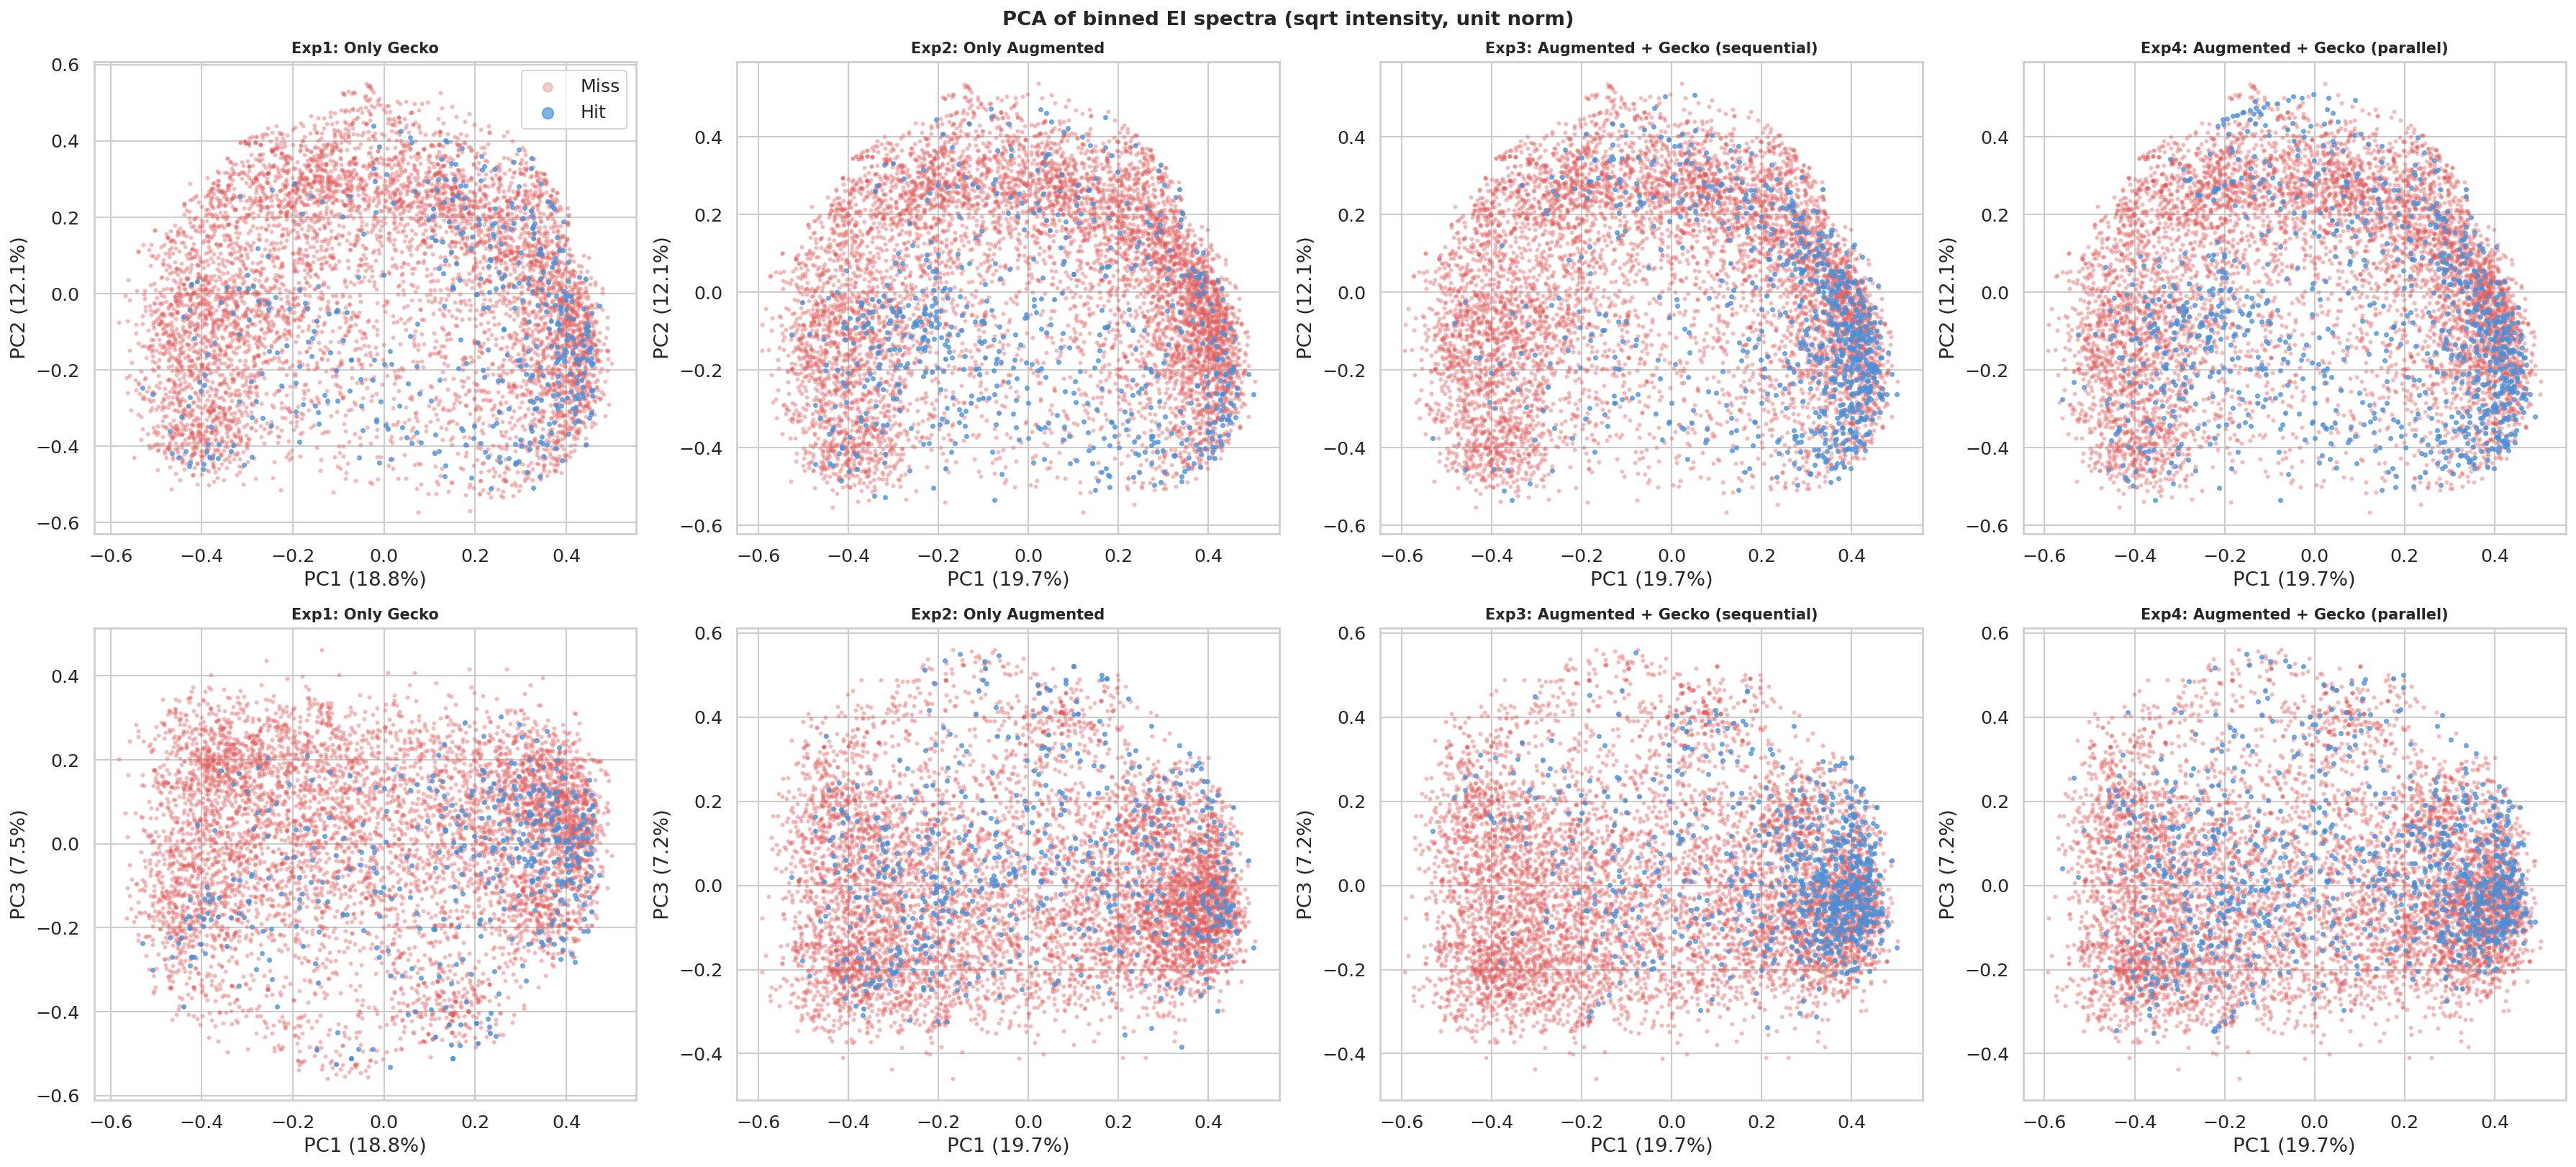

[Exp4: Augmented + Gecko (parallel)] spectral PC loadings


,PC,var,top + m/z,top − m/z,ρ with hit10
0,PC1,0.197,"43, 29, 31, 45, 42, 57, 27, 44","77, 79, 65, 91, 78, 93, 51, 107",0.113
1,PC2,0.121,"69, 55, 83, 70, 71, 56, 57, 84","63, 76, 75, 46, 62, 15, 64, 77",-0.141
2,PC3,0.072,"39, 41, 53, 51, 27, 52, 38, 54","45, 73, 59, 87, 60, 101, 74, 88",0.069
3,PC4,0.040,"57, 39, 89, 103, 102, 56, 87, 115","31, 81, 95, 109, 45, 96, 82, 110",-0.140
4,PC5,0.035,"43, 91, 59, 41, 107, 121, 105, 55","50, 100, 51, 113, 99, 49, 127, 37",-0.178


In [14]:
exp_spec_pca = {}
fig, axes = plt.subplots(2, len(exp_dfs), figsize=(6 * len(exp_dfs), 11), dpi=PLOT_DPI)
for col_i, (exp_name, adf) in enumerate(exp_dfs.items()):
    X = test_binned[adf['spec_idx'].values]
    keep = X.std(axis=0) > 0
    pca = PCA(n_components=10, random_state=42)
    pcs = pca.fit_transform(X[:, keep])
    exp_spec_pca[exp_name] = {'pcs': pcs, 'pca': pca, 'mz': np.arange(MAX_MZ + 1)[keep], 'X': X}
    hit = adf['hit_top10'].values
    for row, (i, j) in enumerate([(0, 1), (0, 2)]):
        ax = axes[row, col_i]
        ax.scatter(pcs[~hit, i], pcs[~hit, j], s=4, alpha=0.3, color=MISS_COLOR, label='Miss', rasterized=True)
        ax.scatter(pcs[hit, i],  pcs[hit, j],  s=6, alpha=0.7, color=HIT_COLOR,  label='Hit',  rasterized=True)
        ev = pca.explained_variance_ratio_
        ax.set_xlabel(f'PC{i+1} ({ev[i]:.1%})'); ax.set_ylabel(f'PC{j+1} ({ev[j]:.1%})')
        ax.set_title(exp_name, fontsize=10, fontweight='bold')
axes[0, 0].legend(markerscale=3)
plt.suptitle('PCA of binned EI spectra (sqrt intensity, unit norm)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/spectral_PCA.png', bbox_inches='tight')
plt.show()

# Loadings: the m/z values that define each PC (same for every experiment up to sign; show the reference exp)
res = exp_spec_pca[EXP_REF]
rows = []
for k in range(5):
    load = res['pca'].components_[k]
    pos = res['mz'][np.argsort(load)[::-1][:8]]
    neg = res['mz'][np.argsort(load)[:8]]
    rho_hit = stats.spearmanr(res['pcs'][:, k], exp_dfs[EXP_REF]['hit_top10'])[0]
    rows.append({'PC': f'PC{k+1}', 'var': res['pca'].explained_variance_ratio_[k],
                 'top + m/z': ', '.join(map(str, pos)), 'top − m/z': ', '.join(map(str, neg)),
                 'ρ with hit10': rho_hit})
print(f'[{EXP_REF}] spectral PC loadings')
display(pd.DataFrame(rows).round(3))

In [15]:
exp_best_k = {}
for exp_name in exp_dfs:
    X = exp_spec_pca[exp_name]['pcs']
    sils = []
    for k in range(2, 11):
        lab = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)
        sils.append(silhouette_score(X, lab, sample_size=min(5000, len(X)), random_state=42))
    exp_best_k[exp_name] = int(np.argmax(sils)) + 2
    print(f'{exp_name}: silhouette per k=2..10: {np.round(sils, 3)} → best k = {exp_best_k[exp_name]}')

# Override k per experiment here if needed, e.g. exp_best_k['Exp1: Only Gecko'] = 6
# Silhouette tends to favour very small k; a slightly larger k gives more interpretable spectral families.
K_OVERRIDE = 6
exp_best_k = {e: max(k, K_OVERRIDE) for e, k in exp_best_k.items()}

exp_spec_clusters = {}
for exp_name, adf in exp_dfs.items():
    K = exp_best_k[exp_name]
    km = KMeans(n_clusters=K, n_init=20, random_state=42).fit(exp_spec_pca[exp_name]['pcs'])
    adf['spec_cluster'] = km.labels_
    X = exp_spec_pca[exp_name]['X']
    # Characteristic ions per cluster = largest mean binned intensity
    top_ions = {c: ', '.join(map(str, np.argsort(X[km.labels_ == c].mean(0))[::-1][:6])) for c in range(K)}
    cs = adf.groupby('spec_cluster').agg(
        n=('hit_top10', 'size'), hit_rate_top1=('hit_top1', 'mean'), hit_rate_top10=('hit_top10', 'mean'),
        tanimoto_top1=('tanimoto_top1', 'mean'), MW=('MW', 'median'), nO=('nO', 'mean'), nN=('nN', 'mean'),
        ArRings=('ArRings', 'mean'), M_rel_inten=('M_rel_inten', 'median'), Entropy=('Entropy', 'median'),
        NOx=('NOx_inten_frac', 'mean'))
    cs['top ions'] = pd.Series(top_ions)
    cs = cs.sort_values('hit_rate_top10')
    exp_spec_clusters[exp_name] = cs
    print(f'\n=== {exp_name}: spectral clusters (k={K}), sorted hardest → easiest ===')
    display(cs.round(3))

Exp1: Only Gecko: silhouette per k=2..10: [0.254 0.238 0.218 0.218 0.212 0.209 0.197 0.211 0.194] → best k = 2


Exp2: Only Augmented: silhouette per k=2..10: [0.265 0.25  0.218 0.216 0.207 0.207 0.204 0.202 0.188] → best k = 2


Exp3: Augmented + Gecko (sequential): silhouette per k=2..10: [0.265 0.25  0.218 0.216 0.207 0.207 0.204 0.202 0.188] → best k = 2


Exp4: Augmented + Gecko (parallel): silhouette per k=2..10: [0.265 0.25  0.218 0.216 0.207 0.207 0.204 0.202 0.188] → best k = 2



=== Exp1: Only Gecko: spectral clusters (k=6), sorted hardest → easiest ===


...

,n,hit_rate_top1,hit_rate_top10,tanimoto_top1,MW,nO,nN,ArRings,M_rel_inten,Entropy,NOx,top ions
spec_cluster,,,,,,,,,,,,
5,1616,0.012,0.032,0.164,216.136,3.575,0.285,0.088,6.106,4.258,0.006,"43, 41, 55, 69, 57, 71"
0,1805,0.006,0.034,0.152,146.058,3.542,0.298,0.001,0.000,3.526,0.027,"43, 41, 57, 29, 45, 42"
1,1092,0.024,0.074,0.140,152.120,1.690,0.439,0.940,62.663,3.736,0.005,"77, 51, 39, 65, 91, 63"
2,1207,0.013,0.084,0.129,126.141,1.264,0.184,0.035,16.917,3.378,0.009,"41, 43, 55, 39, 57, 27"
3,838,0.070,0.153,0.207,240.044,2.272,0.309,1.383,68.919,4.106,0.003,"51, 63, 50, 77, 69, 75"
4,942,0.055,0.197,0.186,120.540,3.558,0.432,0.001,0.000,3.185,0.069,"43, 29, 45, 27, 31, 44"



=== Exp3: Augmented + Gecko (sequential): spectral clusters (k=6), sorted hardest → easiest ===


,n,hit_rate_top1,hit_rate_top10,tanimoto_top1,MW,nO,nN,ArRings,M_rel_inten,Entropy,NOx,top ions
spec_cluster,,,,,,,,,,,,
3,838,0.019,0.024,0.078,240.044,2.272,0.309,1.383,68.919,4.106,0.003,"51, 63, 50, 77, 69, 75"
1,1092,0.018,0.036,0.107,152.120,1.690,0.439,0.940,62.663,3.736,0.005,"77, 51, 39, 65, 91, 63"
5,1616,0.016,0.046,0.192,216.136,3.575,0.285,0.088,6.106,4.258,0.006,"43, 41, 55, 69, 57, 71"
2,1207,0.031,0.094,0.161,126.141,1.264,0.184,0.035,16.917,3.378,0.009,"41, 43, 55, 39, 57, 27"
0,1805,0.043,0.150,0.245,146.058,3.542,0.298,0.001,0.000,3.526,0.027,"43, 41, 57, 29, 45, 42"
4,942,0.097,0.281,0.263,120.540,3.558,0.432,0.001,0.000,3.185,0.069,"43, 29, 45, 27, 31, 44"



=== Exp4: Augmented + Gecko (parallel): spectral clusters (k=6), sorted hardest → easiest ===


,n,hit_rate_top1,hit_rate_top10,tanimoto_top1,MW,nO,nN,ArRings,M_rel_inten,Entropy,NOx,top ions
spec_cluster,,,,,,,,,,,,
5,1616,0.028,0.066,0.223,216.136,3.575,0.285,0.088,6.106,4.258,0.006,"43, 41, 55, 69, 57, 71"
1,1092,0.027,0.091,0.155,152.120,1.690,0.439,0.940,62.663,3.736,0.005,"77, 51, 39, 65, 91, 63"
0,1805,0.027,0.102,0.226,146.058,3.542,0.298,0.001,0.000,3.526,0.027,"43, 41, 57, 29, 45, 42"
2,1207,0.031,0.118,0.169,126.141,1.264,0.184,0.035,16.917,3.378,0.009,"41, 43, 55, 39, 57, 27"
3,838,0.075,0.168,0.212,240.044,2.272,0.309,1.383,68.919,4.106,0.003,"51, 63, 50, 77, 69, 75"
4,942,0.088,0.300,0.253,120.540,3.558,0.432,0.001,0.000,3.185,0.069,"43, 29, 45, 27, 31, 44"



=== Exp1: Only Gecko ===
Hardest spectral cluster C3 (hit10 = 0.015) — misses


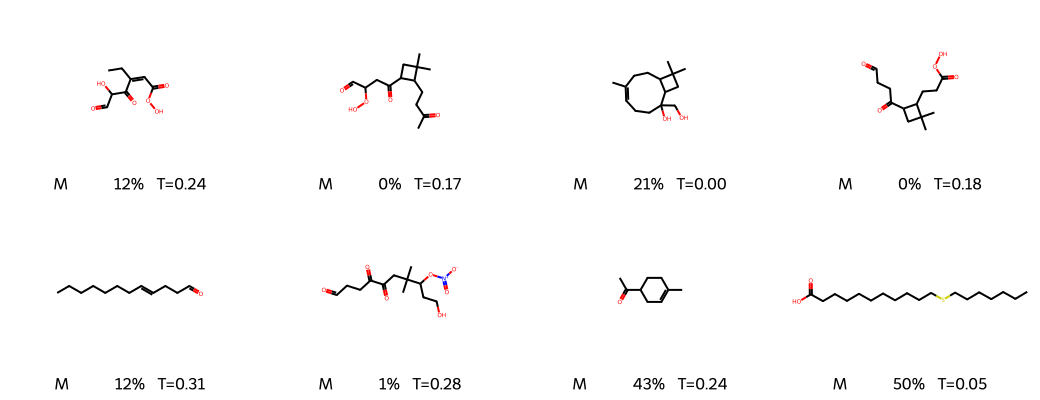

Easiest spectral cluster C5 (hit10 = 0.128) — hits


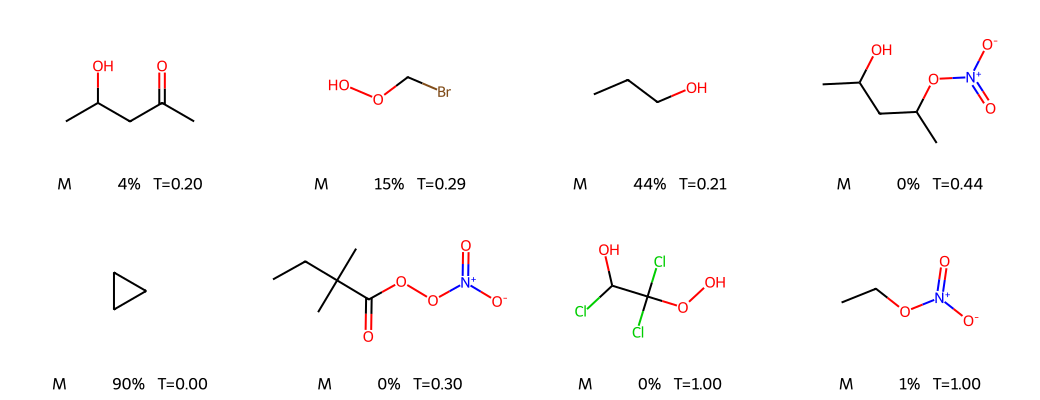


=== Exp2: Only Augmented ===
Hardest spectral cluster C5 (hit10 = 0.032) — misses


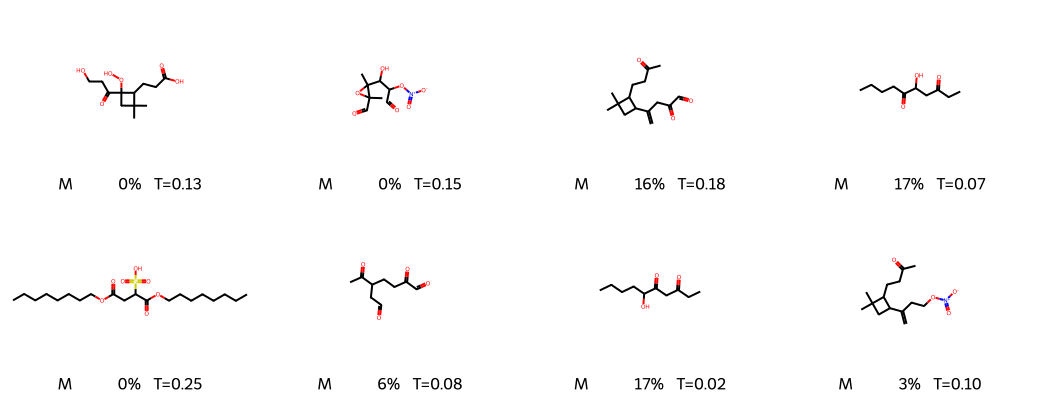

Easiest spectral cluster C4 (hit10 = 0.197) — hits


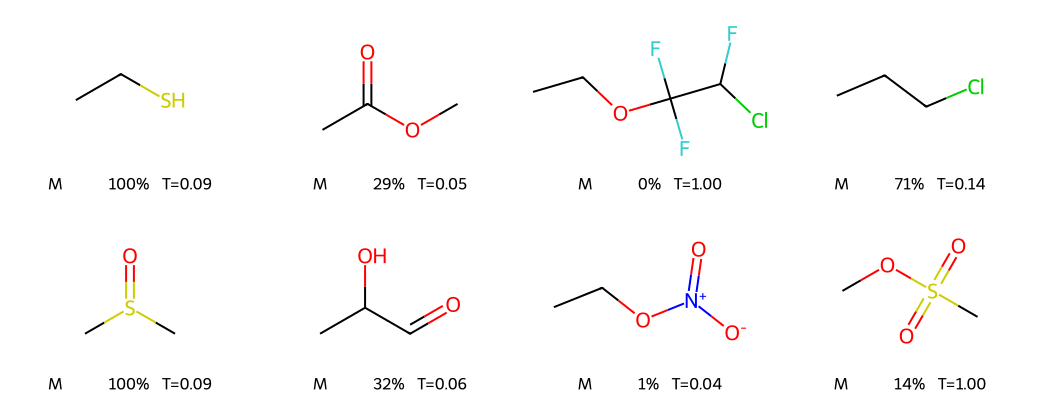


=== Exp3: Augmented + Gecko (sequential) ===
Hardest spectral cluster C3 (hit10 = 0.024) — misses


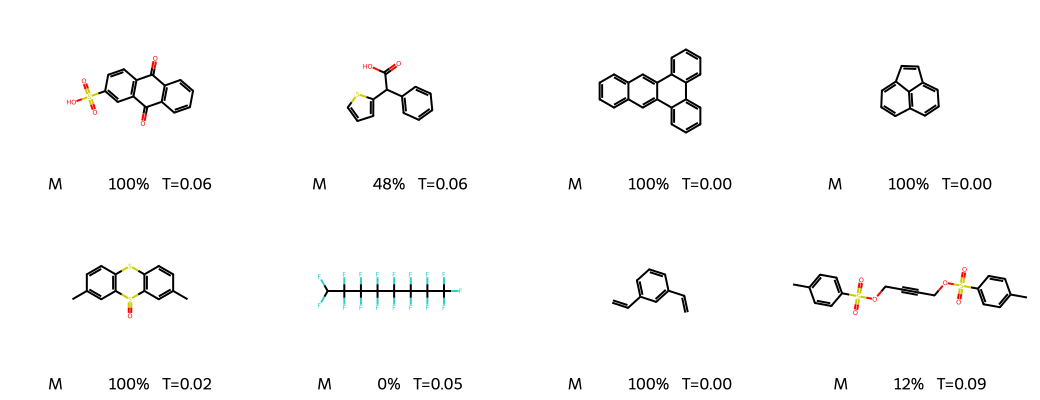

Easiest spectral cluster C4 (hit10 = 0.281) — hits


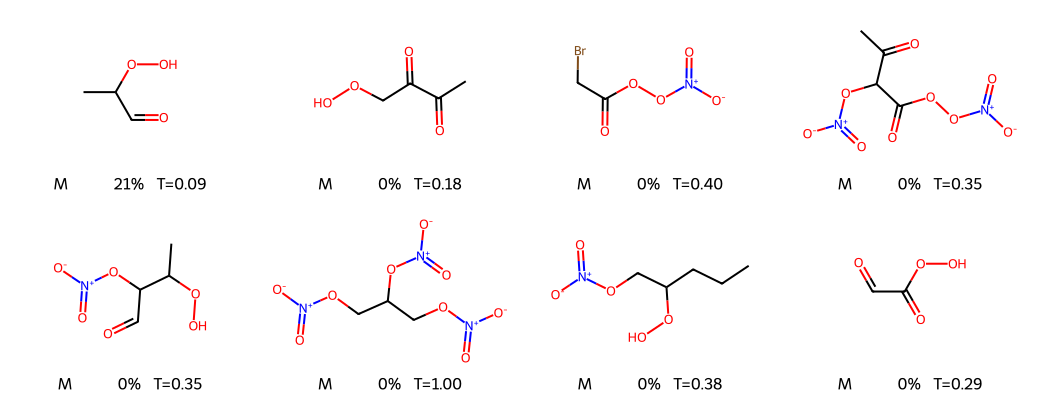


=== Exp4: Augmented + Gecko (parallel) ===
Hardest spectral cluster C5 (hit10 = 0.066) — misses


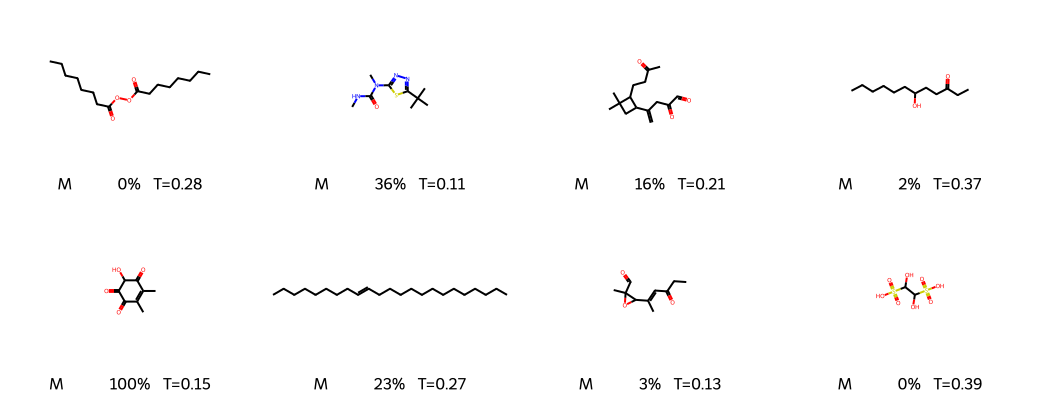

Easiest spectral cluster C4 (hit10 = 0.300) — hits


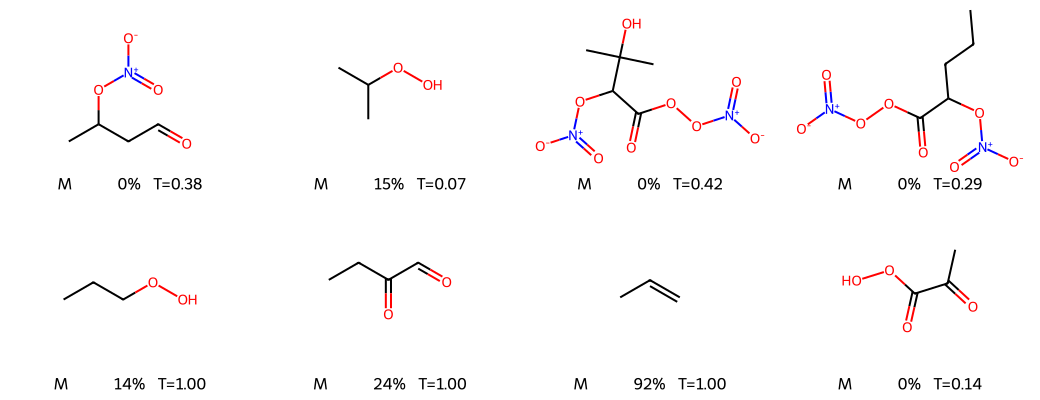

In [16]:
def draw_cluster_examples(adf, cluster_id, hit_filter, n=8, seed=0):
    idx = adf.index[(adf['spec_cluster'] == cluster_id) & (adf['hit_top10'] == hit_filter)].tolist()
    if not idx:
        print('  No molecules found.'); return None
    idx = np.random.default_rng(seed).choice(idx, min(n, len(idx)), replace=False)
    mols = [test_spec['mol'].iloc[adf.loc[i, 'spec_idx']] for i in idx]
    return Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(260, 200),
                                legends=[f"M⁺ {adf.loc[i, 'M_rel_inten']:.0f}%  T={adf.loc[i, 'tanimoto_top1']:.2f}" for i in idx])

for exp_name, adf in exp_dfs.items():
    cs = exp_spec_clusters[exp_name]
    hardest, easiest = cs.index[0], cs.index[-1]
    print(f'\n=== {exp_name} ===\nHardest spectral cluster C{hardest} (hit10 = {cs.loc[hardest, "hit_rate_top10"]:.3f}) — misses')
    img = draw_cluster_examples(adf, hardest, False)
    if img: display(img)
    print(f'Easiest spectral cluster C{easiest} (hit10 = {cs.loc[easiest, "hit_rate_top10"]:.3f}) — hits')
    img = draw_cluster_examples(adf, easiest, True)
    if img: display(img)

## 10. Spectral novelty and ambiguity: nearest neighbours in the training library
For every test spectrum we find its most similar training spectrum (cosine on the binned representation) separately
in the `gecko_new` and `mix_aug` libraries, and compute the **structural** Tanimoto between the test molecule and that
nearest spectral neighbour.

* **NN cosine** — how novel the spectrum is relative to what the model has seen.
* **NN structural Tanimoto** — whether spectral similarity implies structural similarity. A test spectrum whose closest
  training spectrum belongs to a *different* structure is intrinsically ambiguous.

`EXP_TRAIN_LIBS` states which library each experiment was trained on (edit if this assumption is wrong). The
library includes the validation rows, since the guarded split file is not available locally; this makes it a
reference library rather than strictly the training set. Results are cached.

In [17]:
EXP_TRAIN_LIBS = {
    'Exp1: Only Gecko': ['gecko_new'],
    'Exp2: Only Augmented': ['mix_aug'],
    'Exp3: Augmented + Gecko (sequential)': ['gecko_new', 'mix_aug'],
    'Exp4: Augmented + Gecko (parallel)': ['gecko_new', 'mix_aug'],
}
NN_CACHE = f'{OUT_DIR}/spectral_nn_cache.npz'
CHUNK = 10_000

if os.path.exists(NN_CACHE):
    nn = dict(np.load(NN_CACHE, allow_pickle=True))
    print(f'Loaded cached nearest neighbours from {NN_CACHE}')
else:
    nn = {}
    for lib in REF_PREFIXES:
        ref = spec_df[spec_df['prefix'] == lib]
        best = np.full(len(test_binned), -1.0, dtype=np.float32)
        arg  = np.zeros(len(test_binned), dtype=np.int64)
        for start in range(0, len(ref), CHUNK):
            R = bin_spectra(list(ref['spec'].iloc[start:start + CHUNK]))
            S = test_binned @ R.T
            j = S.argmax(1)
            s = S[np.arange(len(S)), j]
            upd = s > best
            best[upd], arg[upd] = s[upd], start + j[upd]
        nn[f'{lib}_cos'] = best
        nn[f'{lib}_smiles'] = ref['SMILES'].values[arg].astype(object)
        print(f'{lib}: {len(ref):,} reference spectra, median NN cosine {np.median(best):.3f}')
    np.savez(NN_CACHE, **nn)

# Structural Tanimoto between each test molecule and its nearest spectral neighbour
test_fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in test_spec['mol']]
for lib in REF_PREFIXES:
    sims = []
    for fp, smi in zip(test_fps, nn[f'{lib}_smiles']):
        m = Chem.MolFromSmiles(smi)
        sims.append(DataStructs.TanimotoSimilarity(fp, AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048)) if m else np.nan)
    nn[f'{lib}_tan'] = np.array(sims)
    print(f'{lib}: identical structure found as NN for {(nn[lib + "_tan"] == 1).sum()} test spectra')

for exp_name, adf in exp_dfs.items():
    libs = EXP_TRAIN_LIBS[exp_name]
    cos = np.column_stack([nn[f'{l}_cos'][adf['spec_idx']] for l in libs])
    tan = np.column_stack([nn[f'{l}_tan'][adf['spec_idx']] for l in libs])
    pick = cos.argmax(1)
    adf['NN_cosine']   = cos[np.arange(len(adf)), pick]
    adf['NN_tanimoto'] = tan[np.arange(len(adf)), pick]
    r_cos = stats.spearmanr(adf['NN_cosine'], adf['hit_top10'])[0]
    r_tan = stats.spearmanr(adf['NN_tanimoto'], adf['hit_top10'])[0]
    print(f'{exp_name} (libs: {"+".join(libs)}): median NN cosine={adf.NN_cosine.median():.3f}  '
          f'ρ(NN cosine, hit10)={r_cos:+.3f}  ρ(NN tanimoto, hit10)={r_tan:+.3f}')

Loaded cached nearest neighbours from spectral_difficulty_analysis/spectral_nn_cache.npz


gecko_new: identical structure found as NN for 0 test spectra


mix_aug: identical structure found as NN for 55 test spectra
Exp1: Only Gecko (libs: gecko_new): median NN cosine=0.884  ρ(NN cosine, hit10)=+0.056  ρ(NN tanimoto, hit10)=+0.120
Exp2: Only Augmented (libs: mix_aug): median NN cosine=0.914  ρ(NN cosine, hit10)=-0.187  ρ(NN tanimoto, hit10)=+0.027
Exp3: Augmented + Gecko (sequential) (libs: gecko_new+mix_aug): median NN cosine=0.925  ρ(NN cosine, hit10)=+0.040  ρ(NN tanimoto, hit10)=+0.093
Exp4: Augmented + Gecko (parallel) (libs: gecko_new+mix_aug): median NN cosine=0.925  ρ(NN cosine, hit10)=-0.113  ρ(NN tanimoto, hit10)=+0.048


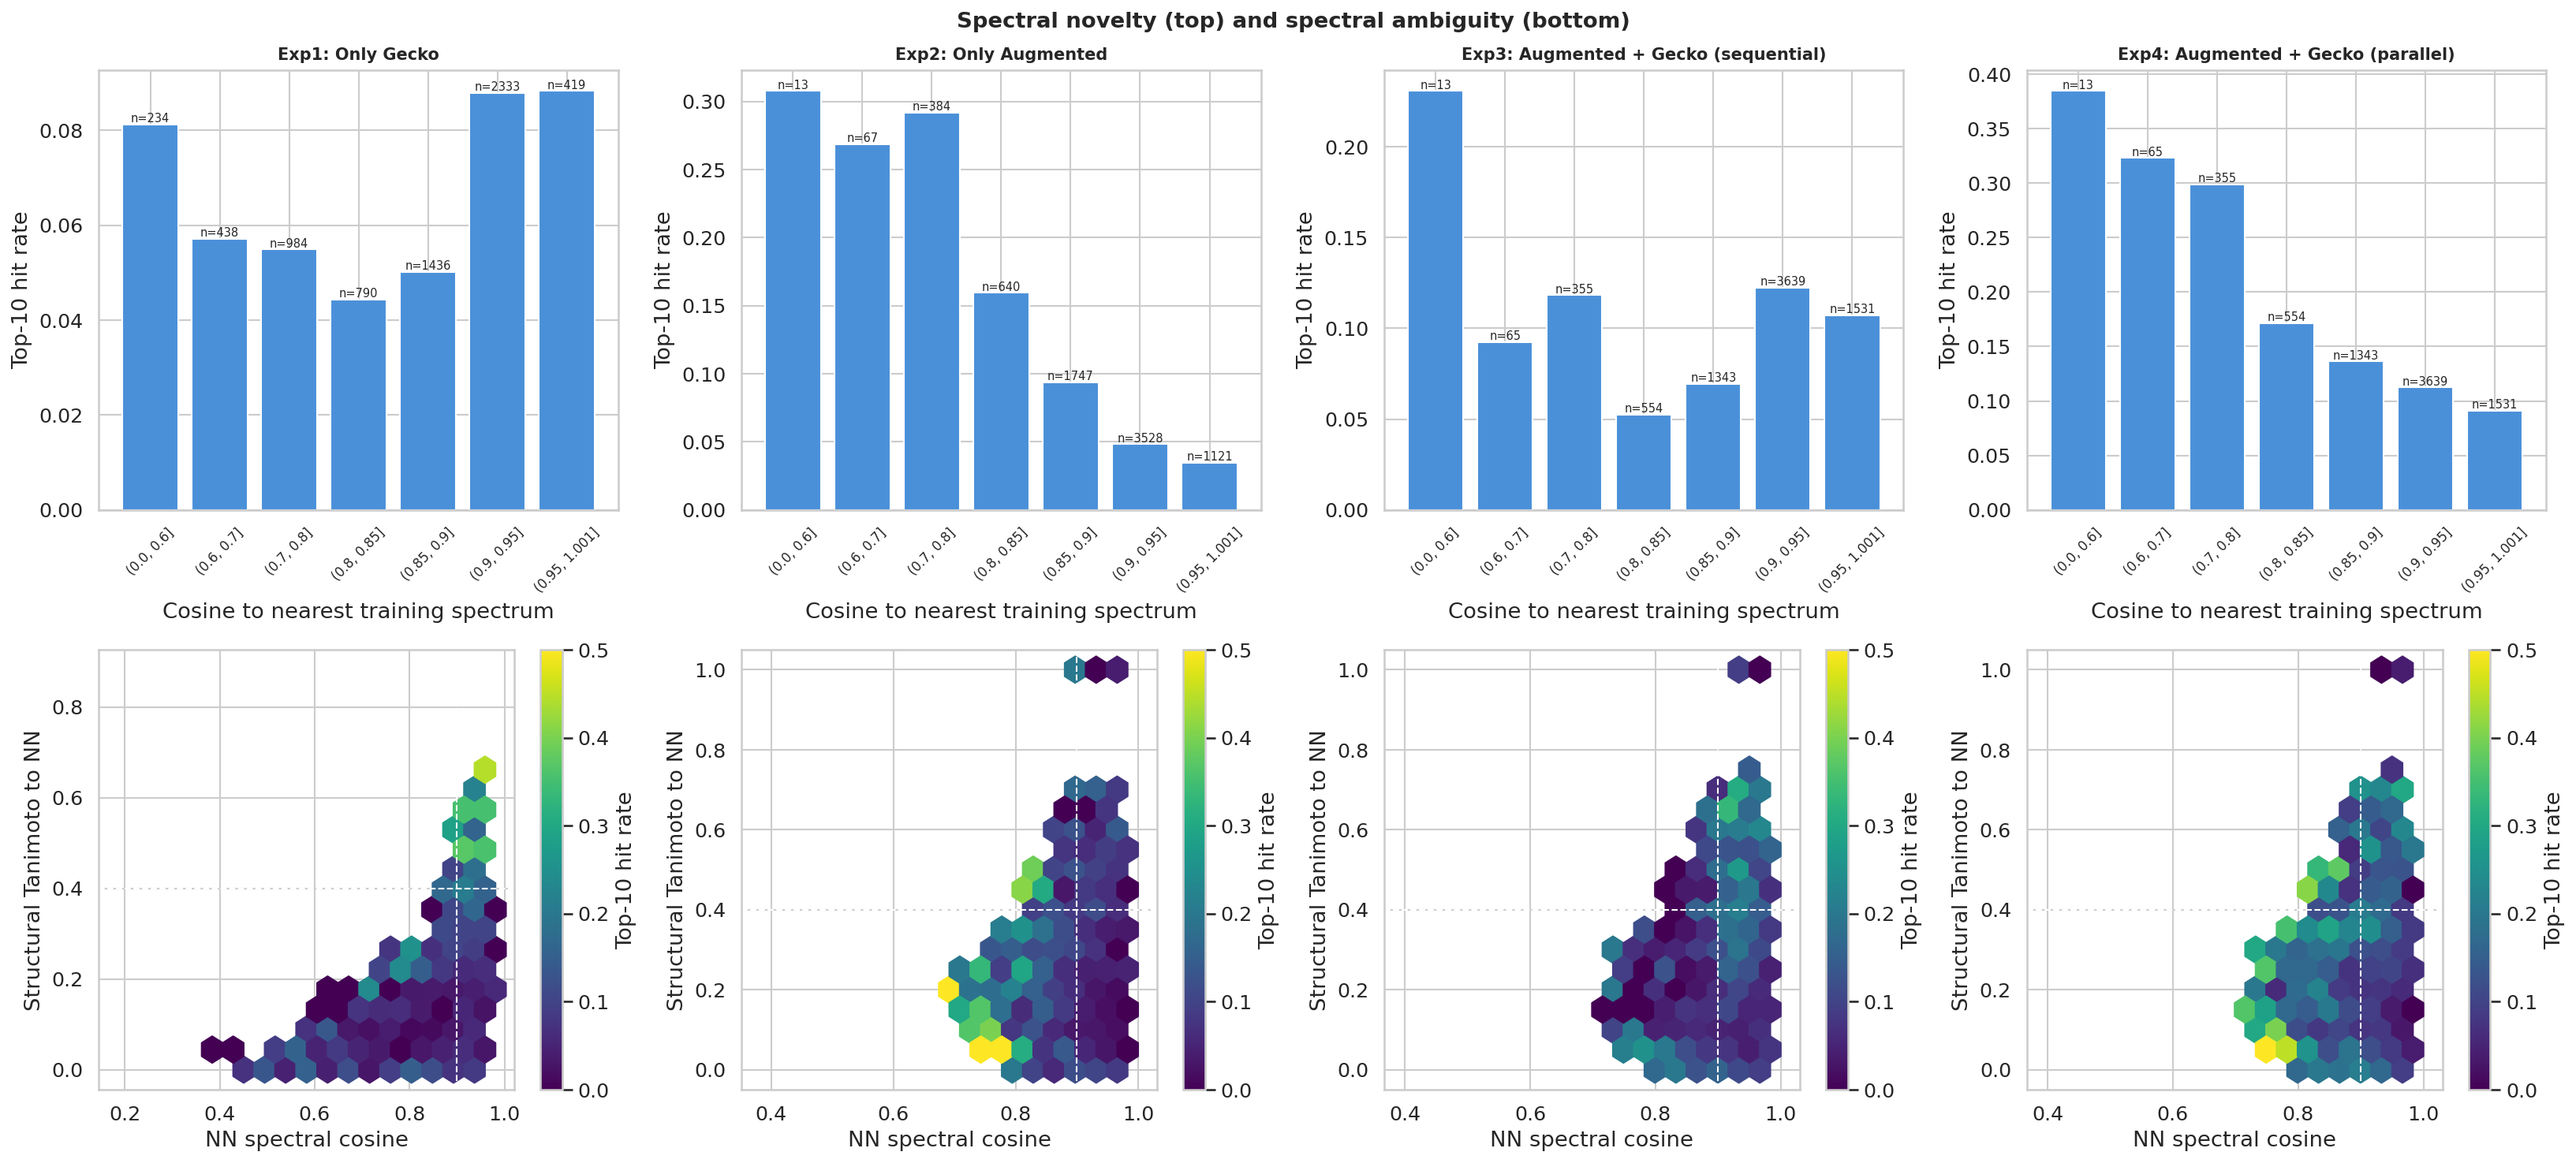

Exp1: Only Gecko


n  hit10  tanimoto
spectral                 structure                                       
close spectrum (cos≥0.9) different structure        2466  0.068     0.211
                         similar structure (T≥0.4)   286  0.259     0.383
far spectrum             different structure        3809  0.049     0.131
                         similar structure (T≥0.4)    73  0.274     0.327

Exp2: Only Augmented


n  hit10  tanimoto
spectral                 structure                                       
close spectrum (cos≥0.9) different structure        3903  0.039     0.138
                         similar structure (T≥0.4)   746  0.074     0.185
far spectrum             different structure        2540  0.134     0.176
                         similar structure (T≥0.4)   311  0.193     0.231

Exp3: Augmented + Gecko (sequential)


n  hit10  tanimoto
spectral                 structure                                       
close spectrum (cos≥0.9) different structure        4090  0.104     0.192
                         similar structure (T≥0.4)  1080  0.171     0.251
far spectrum             different structure        2023  0.077     0.135
                         similar structure (T≥0.4)   307  0.055     0.148

Exp4: Augmented + Gecko (parallel)


n  hit10  tanimoto
spectral                 structure                                       
close spectrum (cos≥0.9) different structure        4090  0.094     0.195
                         similar structure (T≥0.4)  1080  0.151     0.264
far spectrum             different structure        2023  0.176     0.195
                         similar structure (T≥0.4)   307  0.173     0.258

In [18]:
COS_BINS = [0, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 1.001]
fig, axes = plt.subplots(2, len(exp_dfs), figsize=(5.5 * len(exp_dfs), 10), dpi=PLOT_DPI)
for col_i, (exp_name, adf) in enumerate(exp_dfs.items()):
    # Top: hit rate vs NN cosine
    ax = axes[0, col_i]
    g = adf.groupby(pd.cut(adf.NN_cosine, COS_BINS), observed=True)['hit_top10'].agg(['mean', 'count'])
    ax.bar(range(len(g)), g['mean'], color=HIT_COLOR)
    for i, n in enumerate(g['count']):
        ax.text(i, g['mean'].iloc[i], f'n={n}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(range(len(g))); ax.set_xticklabels([str(iv) for iv in g.index], rotation=45, fontsize=8)
    ax.set_xlabel('Cosine to nearest training spectrum'); ax.set_ylabel('Top-10 hit rate')
    ax.set_title(exp_name, fontsize=10, fontweight='bold')

    # Bottom: spectral vs structural similarity of the NN, coloured by hit rate
    ax = axes[1, col_i]
    hb = ax.hexbin(adf.NN_cosine, adf.NN_tanimoto, C=adf.hit_top10.astype(float), reduce_C_function=np.mean,
                   gridsize=18, cmap='viridis', mincnt=8, vmin=0, vmax=0.5)
    ax.axvline(0.9, color='w', ls='--', lw=1); ax.axhline(0.4, color='w', ls='--', lw=1)
    ax.set_xlabel('NN spectral cosine'); ax.set_ylabel('Structural Tanimoto to NN')
    plt.colorbar(hb, ax=ax, label='Top-10 hit rate')
plt.suptitle('Spectral novelty (top) and spectral ambiguity (bottom)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/nn_novelty_ambiguity.png', bbox_inches='tight')
plt.show()

# Quadrant table: spectrally close/far × structurally close/far
for exp_name, adf in exp_dfs.items():
    q = adf.assign(spectral=np.where(adf.NN_cosine >= 0.9, 'close spectrum (cos≥0.9)', 'far spectrum'),
                   structure=np.where(adf.NN_tanimoto >= 0.4, 'similar structure (T≥0.4)', 'different structure'))
    print(exp_name)
    display(q.groupby(['spectral', 'structure']).agg(n=('hit_top10', 'size'), hit10=('hit_top10', 'mean'),
                                                     tanimoto=('tanimoto_top1', 'mean')).round(3))

In [19]:
# Does NN information add predictive value on top of molecular + spectral summary features?
NN_COLS = ['NN_cosine', 'NN_tanimoto']
FEATURE_SETS_NN = {'molecular': MOL_COLS, 'combined': MOL_COLS + SPEC_COLS,
                   'combined + NN': MOL_COLS + SPEC_COLS + NN_COLS, 'NN only': NN_COLS}
rows = []
for exp_name, adf in exp_dfs.items():
    y = adf['hit_top10'].astype(int).values
    for fs_name, cols in FEATURE_SETS_NN.items():
        clf = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                                             l2_regularization=1.0, random_state=42)
        prob = cross_val_predict(clf, adf[cols].values, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                 method='predict_proba')[:, 1]
        rows.append({'Experiment': exp_name.split(':')[0], 'Features': fs_name,
                     'ROC-AUC': roc_auc_score(y, prob), 'AP': average_precision_score(y, prob)})
display(pd.DataFrame(rows).pivot(index='Features', columns='Experiment', values='ROC-AUC')
        .loc[list(FEATURE_SETS_NN)].round(3))

Experiment,Exp1,Exp2,Exp3,Exp4
Features,,,,
molecular,0.888,0.901,0.891,0.853
combined,0.870,0.900,0.886,0.852
combined + NN,0.879,0.900,0.887,0.852
NN only,0.687,0.705,0.621,0.617


## 11. Example spectra: hits vs misses of similar mass
Stick spectra of randomly chosen hits and misses in the same MW window, so the contrast isn't driven by size. Dashed line = M.

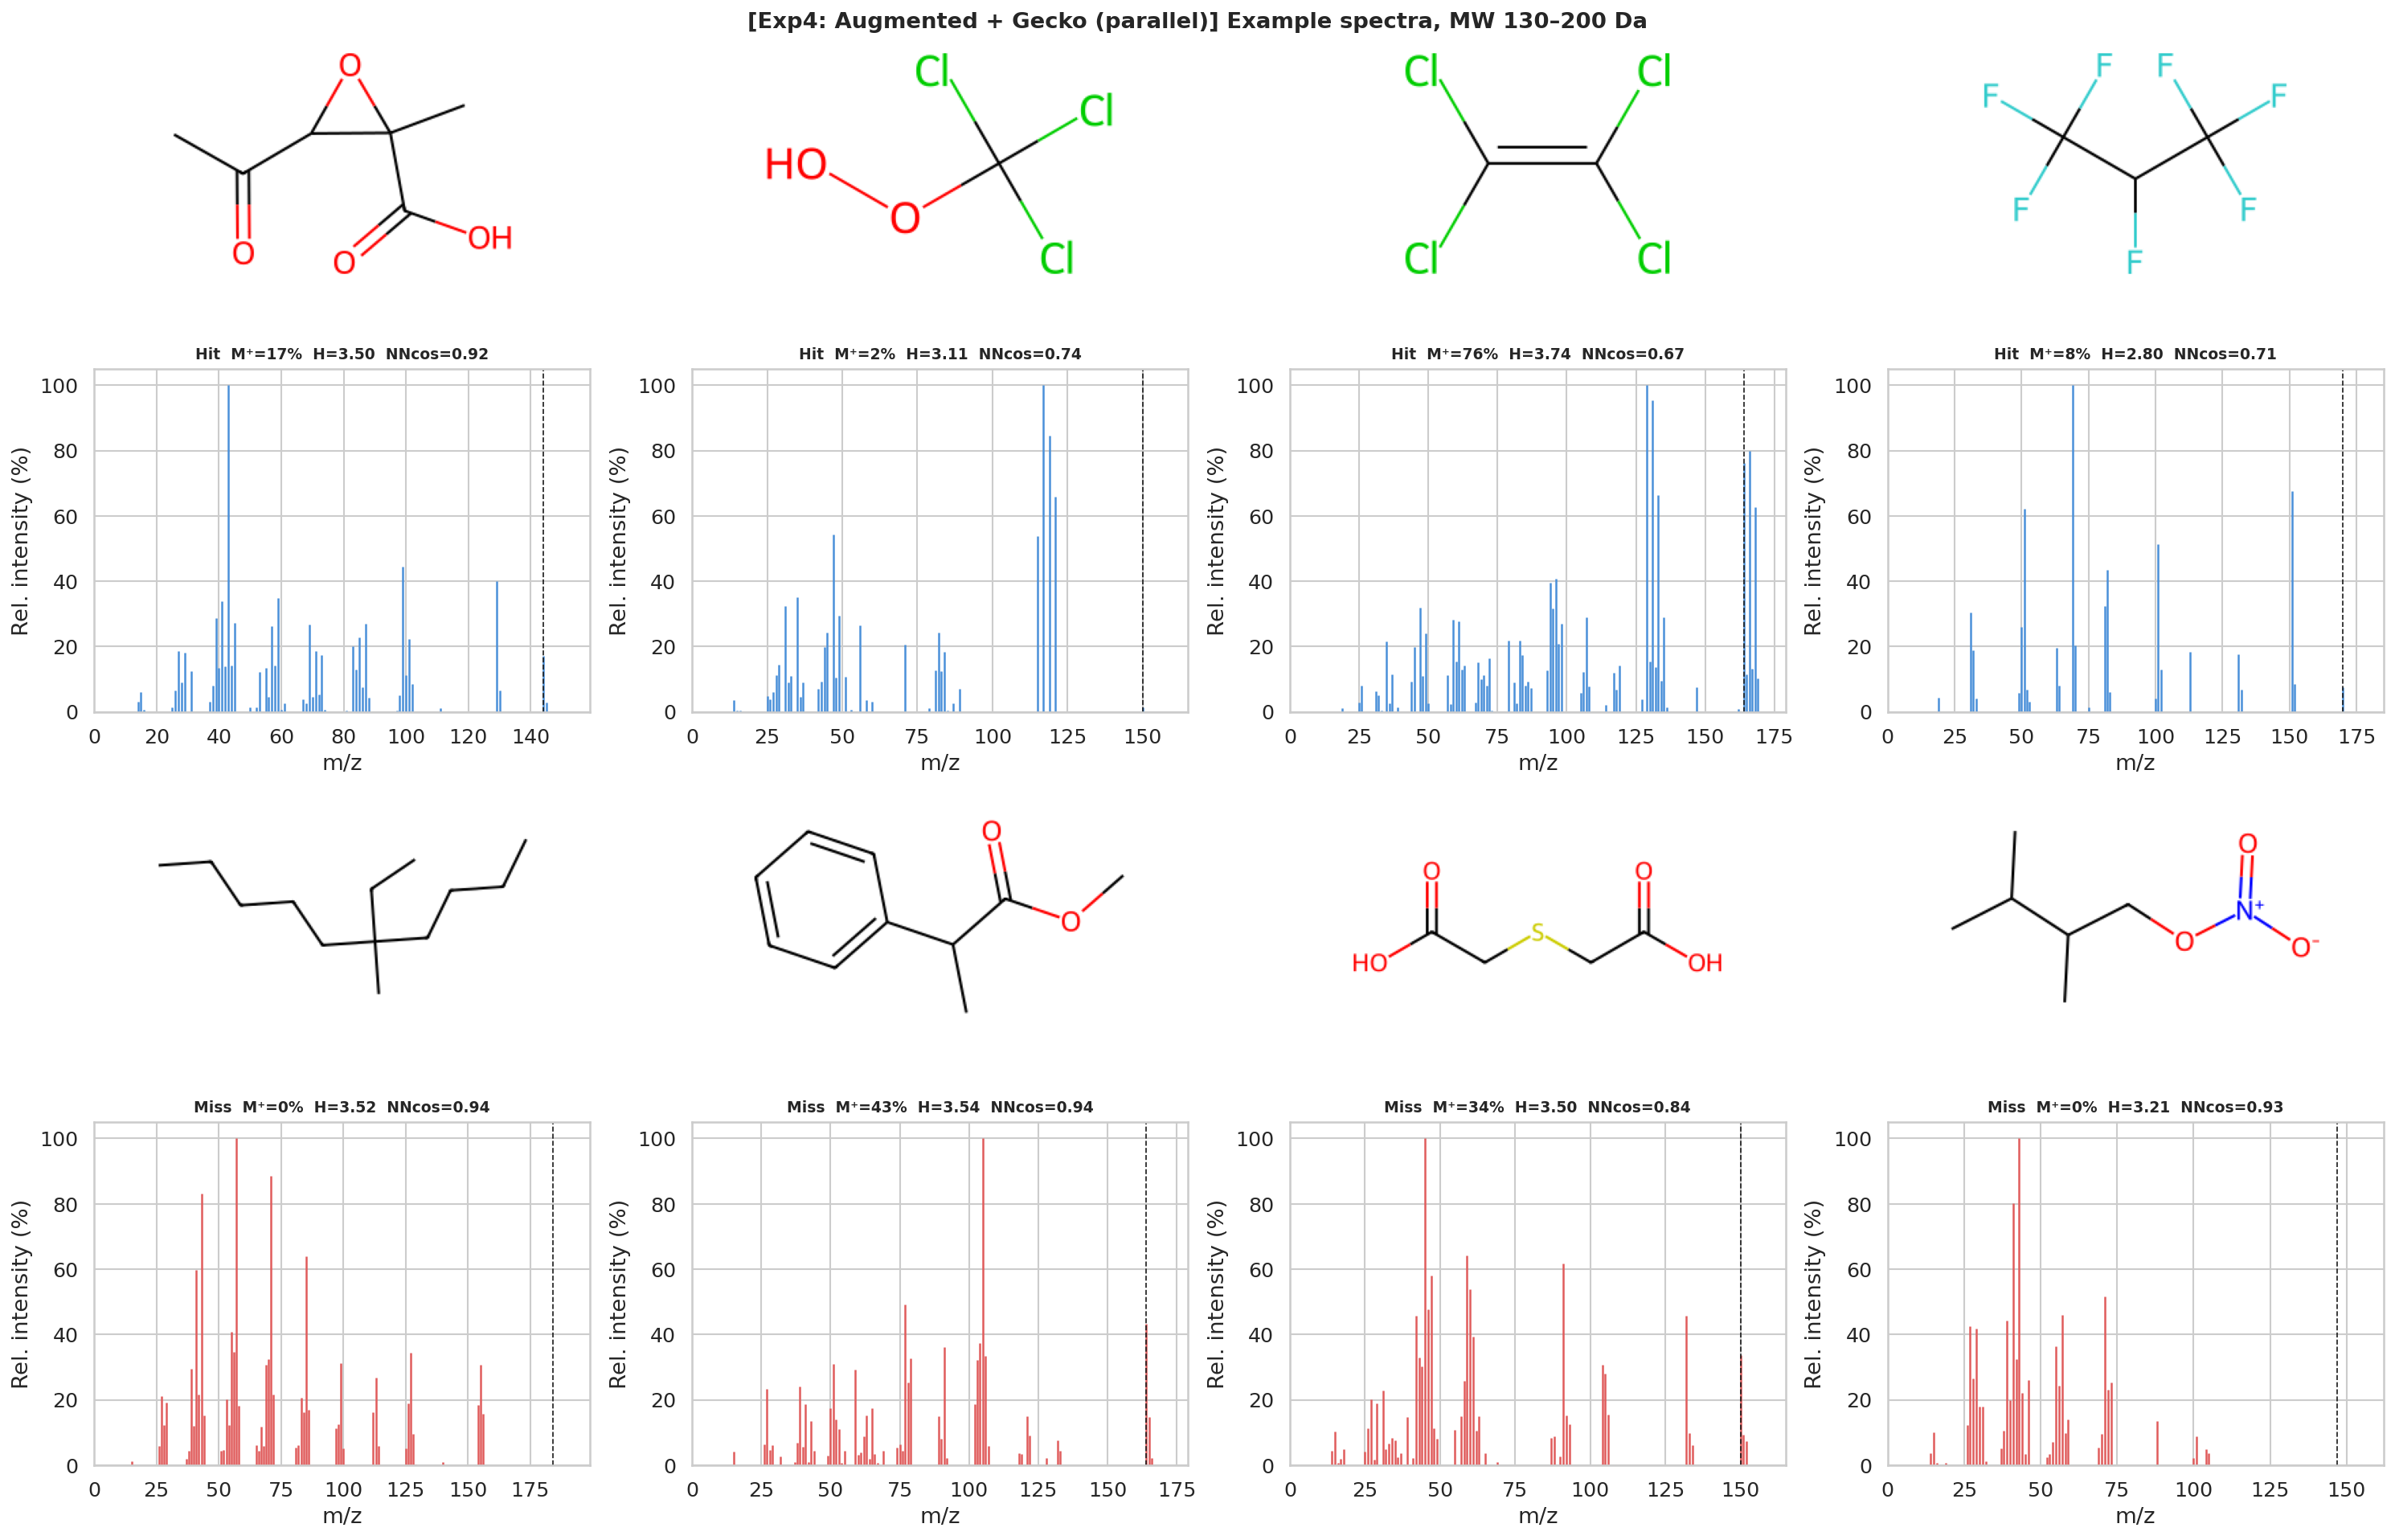

In [20]:
EXAMPLE_EXP = 'Exp4: Augmented + Gecko (parallel)'
MW_WINDOW   = (130, 200)
N_EACH      = 4

adf = exp_dfs[EXAMPLE_EXP]
win = adf[adf.MW.between(*MW_WINDOW)]
rng = np.random.default_rng(1)
picks = {'Hit': rng.choice(win.index[win.hit_top10], N_EACH, replace=False),
         'Miss': rng.choice(win.index[~win.hit_top10], N_EACH, replace=False)}

fig, axes = plt.subplots(4, N_EACH, figsize=(5 * N_EACH, 13), dpi=PLOT_DPI,
                         gridspec_kw={'height_ratios': [1, 1.4, 1, 1.4]})
for row, (label, idxs) in enumerate(picks.items()):
    for col, i in enumerate(idxs):
        r = adf.loc[i]
        spec, mol = test_spec['spec'].iloc[r.spec_idx], test_spec['mol'].iloc[r.spec_idx]
        ax_mol, ax = axes[2 * row, col], axes[2 * row + 1, col]
        ax_mol.imshow(Draw.MolToImage(mol, size=(300, 180))); ax_mol.axis('off')
        rel = 100 * spec[:, 1] / spec[:, 1].max()
        ax.vlines(spec[:, 0], 0, rel, color=HIT_COLOR if label == 'Hit' else MISS_COLOR, lw=1.2)
        ax.axvline(r.NominalMass, color='k', ls='--', lw=0.8)
        ax.set_xlim(0, r.NominalMass + 15); ax.set_ylim(0, 105)
        ax.set_title(f'{label}  M⁺={r.M_rel_inten:.0f}%  H={r.Entropy:.2f}  NNcos={r.NN_cosine:.2f}', fontsize=9, fontweight='bold')
        ax.set_xlabel('m/z'); ax.set_ylabel('Rel. intensity (%)')
plt.suptitle(f'[{EXAMPLE_EXP}] Example spectra, MW {MW_WINDOW[0]}–{MW_WINDOW[1]} Da', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/example_spectra.png', bbox_inches='tight')
plt.show()

## 12. Save results

In [21]:
for exp_name, adf in exp_dfs.items():
    tag = exp_name.split(':')[0]
    exp_hm_stats[exp_name].to_csv(f'{OUT_DIR}/results_{tag}_spectral_hit_miss.csv')
    exp_spec_clusters[exp_name].to_csv(f'{OUT_DIR}/results_{tag}_spectral_clusters.csv')
    adf.drop(columns=['true_inchikey']).to_csv(f'{OUT_DIR}/results_{tag}_per_molecule.csv', index=False)
rho_mat.to_csv(f'{OUT_DIR}/results_spectral_tanimoto_rho.csv')
part_df.to_csv(f'{OUT_DIR}/results_partial_correlations.csv', index=False)
ml_df.to_csv(f'{OUT_DIR}/results_difficulty_prediction.csv', index=False)
print('Saved results to', OUT_DIR)

Saved results to spectral_difficulty_analysis


## 13. Findings

**Data linkage.** 99.3–99.4 % of test molecules were linked to their NEIMS spectrum (97.8 % by canonical SMILES, the rest by
InChIKey). The 48 unlinked molecules have almost no hits, so dropping them does not bias the results.

**1. Rich, complex spectra are harder, but this is mostly molecular size.** In every experiment, misses have more peaks
(median 63 vs 48), higher spectral entropy and a flatter intensity distribution (rank-biserial r ≈ −0.30 to −0.37). After
controlling for MW and heavy-atom count, these effects shrink from ρ ≈ −0.17 to −0.02…−0.10 (Section 7). A complex
spectrum mostly signals a large molecule, and size was already the main difficulty factor in the molecular notebook.

**2. Which spectra count as "easy" depends on the training data.**
* Models trained with GECKO (Exp1, Exp3) do best on spectra dominated by **low-m/z, generic and NO⁺/NO₂⁺ ions (m/z 30, 46)**
  with a weak or absent molecular ion, i.e. small oxygenated/nitrated atmospheric-type compounds. These effects survive
  the size control (Exp3 partial ρ: LowMz +0.25, NOx +0.21, MaxMz_frac −0.15). In Exp3 the median M⁺ intensity of hits is 0 %.
* The augmented-only model (Exp2) shows the opposite pattern. It succeeds on spectra with a **strong molecular ion and
  high-mass signal** (MaxMz_frac r = +0.41; M⁺ absent → 4.1 % hit rate vs 11 % when M⁺ ≥ 10 %).
* Exp4 (parallel) sits between the two and has the flattest profile. Its only consistent correlates are the size-related
  complexity features.
* No spectral property makes a molecule easy for every model. The molecular-ion observation is the clearest example:
  chemists treat M⁺ as highly informative, but it helps only Exp2.

**3. Top-1 Tanimoto has stronger, size-independent spectral correlates than exact hits.** Signal at high m/z (M⁺ intensity,
MaxMz_frac, WeightedMz_frac, HighMass fraction) goes with *lower* top-1 similarity (partial ρ ≈ −0.45 to −0.49 in Exp1/Exp3,
≈ −0.33 in Exp4, ≈ −0.12 in Exp2). Low-m/z, generic and NOx signal goes with *higher* similarity (+0.3 to +0.5). These
correlations barely change after controlling for size, so they track **compound class** (point 4) rather than molecule size.

**4. Spectral families (k-means on binned spectra, k = 6; the clusters are identical for Exp2–4 because they share a test set):**
| family (characteristic ions) | typical molecules | top-10 hit rate |
|---|---|---|
| 43, 29, 45, 31, 44 (+ NOx) | small O-rich / nitrated aliphatics, M⁺ absent | **easiest in every experiment** (13–30 %) |
| 43, 41, 57, 55, 29 | O-containing aliphatics, M⁺ absent | medium (3–15 %) |
| 41, 43, 55, 39, 27 | small alkenes / cyclics | medium (8–12 %) |
| 77, 51, 91, 65, 39 | mono-aromatics, strong M⁺ | hard (4–9 %) |
| 51, 63, 50, 75, 69 | substituted / halogenated aromatics, strong M⁺ | very hard with GECKO-only training (2–5 %), easiest after 4 with augmented data (15–17 %) |
| 43, 41, 55, 69, 57, 71 | long alkyl chains, MW ≈ 220, weak M⁺, high entropy | hardest in 3 of 4 experiments (1.5–7 %) |

The alkyl-chain family matches the long-hydrocarbon ladder in the molecular PCA. The aromatic families explain the negative
M⁺/Tanimoto correlation in point 3: strong M⁺ spectra come from aromatics, which the atmospheric training data covers poorly.

**5. The spectral summary features add no predictive information beyond structure.** Gradient boosting on spectral
features alone predicts top-10 success well (ROC-AUC 0.79–0.84). However, the combined model never beats molecular
descriptors alone (0.85–0.90 in both cases, with average precision equal or slightly lower). Permutation importance is
dominated by nC, TPSA, Fsp3, nS and nHalogen. The only spectral features with non-trivial importance are
LowMz_inten_frac (Exp3) and NOx_inten_frac, which in effect encode compound class.

**6. Spectral novelty and ambiguity matter less than expected.**
* Test spectra are close to the training libraries (median nearest-neighbour cosine 0.88–0.93). How close the nearest
  neighbour is correlates only weakly and inconsistently with success (ρ −0.19…+0.06), and NN features on their own reach
  AUC 0.62–0.71 and add nothing to the combined model.
* Spectral ambiguity is widespread: for 55–60 % of test spectra, the nearest training spectrum has cosine ≥ 0.9 but belongs
  to a structurally different molecule (Tanimoto < 0.4). Unit-mass EI spectra are far from unique.
* When the nearest spectral neighbour *is* structurally similar, success rises. The effect is clearest for Exp1 (26 %
  hit rate vs 5–7 % otherwise) and Exp3 (17 % vs 10 %).
* 52–55 test molecules have a mix_aug nearest neighbour with Morgan Tanimoto = 1, but the cosine is ≈ 0.96 rather than 1.
  These are isomers that collide in the fingerprint, not the same molecule, so there is no leakage.

**Takeaway.** Across all four models, the spectral correlates of difficulty mostly restate the molecular ones: size (peak
count/entropy), then compound class (aromatic vs oxygenated/nitrated aliphatic, alkyl chains). Once structure is known,
the spectrum carries little extra difficulty information. The main spectrum-specific result is that training data sets
what counts as an informative spectrum: GECKO-trained models rely on low-mass oxygenate/NOx fragments, while the
augmented-data model relies on the molecular ion and high-mass fragments. This suggests the models under-use
high-mass information when trained on GECKO, and that more aromatic and long-chain training spectra are the most direct
way to address the hardest spectral families.